We are doing this eda for
- Feature Selection (which column is related to the target prediction)
- Impute the missing values in the data

# Import Packages and Loading the Dataset

In [1]:
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import plotly.express as px
import missingno as msno
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df_final = pd.read_csv('A:/CODES/PROJECTS/swiggy_delivery_time_prediction/data/raw/swiggy_cleaned.csv')
df_final.sample(30)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
20849,SURRES11DEL02,21.0,5.0,21.157735,72.768778,21.237735,72.848778,2022-04-02,sandstorms,medium,...,18,SUR,2,4,saturday,1,15.0,17.0,evening,12.162116
9086,LUDHRES17DEL03,34.0,4.5,30.893384,75.821202,30.983384,75.911202,2022-02-12,windy,jam,...,39,LUDH,12,2,saturday,1,10.0,20.0,night,13.184476
15069,MYSRES11DEL01,24.0,4.4,12.323225,76.630028,12.433225,76.740028,2022-04-06,fog,medium,...,31,MYS,6,4,wednesday,0,15.0,17.0,evening,17.097997
14211,GOARES07DEL02,24.0,4.7,15.561295,73.749478,15.611295,73.799478,2022-02-15,cloudy,low,...,14,GOA,15,2,tuesday,0,15.0,23.0,night,7.719455
13811,INDORES09DEL01,38.0,4.8,22.725835,75.887648,22.735835,75.897648,2022-04-03,cloudy,low,...,21,INDO,3,4,sunday,1,10.0,8.0,morning,1.512698
41115,RANCHIRES18DEL02,30.0,4.7,23.351489,85.324253,23.401489,85.374253,2022-03-11,sunny,jam,...,22,RANCHI,11,3,friday,0,15.0,19.0,evening,7.546877
22927,MUMRES05DEL01,20.0,4.6,18.927584,72.832585,19.037584,72.942585,2022-03-27,fog,medium,...,26,MUM,27,3,sunday,1,10.0,18.0,evening,16.834091
33666,AGRRES16DEL03,24.0,4.4,NaN,NaN,NaN,NaN,2022-02-11,stormy,low,...,23,AGR,11,2,friday,0,10.0,23.0,night,NaN
25371,RANCHIRES06DEL02,30.0,4.6,23.357804,85.325146,23.437804,85.405146,2022-03-16,fog,jam,...,52,RANCHI,16,3,wednesday,0,5.0,20.0,night,12.074114
8868,COIMBRES15DEL03,35.0,4.5,11.006686,76.951736,11.036686,76.981736,2022-03-30,sandstorms,low,...,29,COIMB,30,3,wednesday,0,10.0,22.0,night,4.674295


# Preliminary Analysis

## Basic Analysis

In [3]:
# check for missing values in the data

df_final.isnull().sum()

rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64

In [4]:
# number of rows in the data that have missing values

missing_rows = (
    df_final
    .isnull()
    .any(axis=1)
    .sum()
)
print(f'There are {missing_rows} rows with missing values in the data.')
print(f"It accounts for {(missing_rows/df_final.shape[0])*100:.2f}% of the data")

There are 7438 rows with missing values in the data.
It accounts for 16.35% of the data


**The initial percentage of missing data was `9.2%` and increased to `16.35%` because we transformed 0 values in the lat long columns to NaN**

In [5]:
# check for duplicate rows in the data

df_final.duplicated().sum()

np.int64(0)

**There are no duplicate rows in the data and none were created by our data cleaning step**

In [6]:
# data types of features

df_final.dtypes

rider_id                    str
age                     float64
ratings                 float64
restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
order_date                  str
weather                     str
traffic                     str
vehicle_condition         int64
type_of_order               str
type_of_vehicle             str
multiple_deliveries     float64
festival                    str
city_type                   str
time_taken                int64
city_name                   str
order_day                 int64
order_month               int64
order_day_of_week           str
is_weekend                int64
pickup_time_minutes     float64
order_time_hour         float64
order_time_of_day           str
distance                float64
dtype: object

In [7]:
# numerical and categorical columns

num_cols = df_final.columns[[1, 2, 3, 4, 5, 6, 16, 22, 25]].tolist()
cat_cols = [col for col in df_final.columns.tolist() if col not in num_cols]

print(f'There are {len(num_cols)} numerical columns and {len(cat_cols)} categorical columns in the data.')

There are 9 numerical columns and 17 categorical columns in the data.


**Observation:**
- Since, there is more categorical columns in the dataset, catboost might work better

In [8]:
num_cols

['age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'time_taken',
 'pickup_time_minutes',
 'distance']

In [9]:
cat_cols

['rider_id',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'city_name',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_hour',
 'order_time_of_day']

In [10]:
# statistical summary of numerical columns

df_final[num_cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,time_taken,pickup_time_minutes,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,26.297591,9.989399,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,9.386419,4.087516,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,10.000000,5.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,19.000000,5.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,26.000000,10.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,32.000000,15.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,15.000000,20.969489


In [11]:
# statistical summary of categorical columns

(
    df_final
    .assign(**{
        col: df_final[col].astype("object")
        for col in cat_cols
    })
    .describe(include="object")
    .T
)

,count,unique,top,freq
rider_id,45502,1320,JAPRES11DEL02,67
order_date,45502,44,2022-03-15,1190
weather,44977,6,fog,7654
traffic,44992,4,low,15477
vehicle_condition,45502,4,2,15034
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
multiple_deliveries,44509.0,4.0,1.0,28109.0
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029


## Missing Value Analysis

### Matrix Plot


<Axes: >

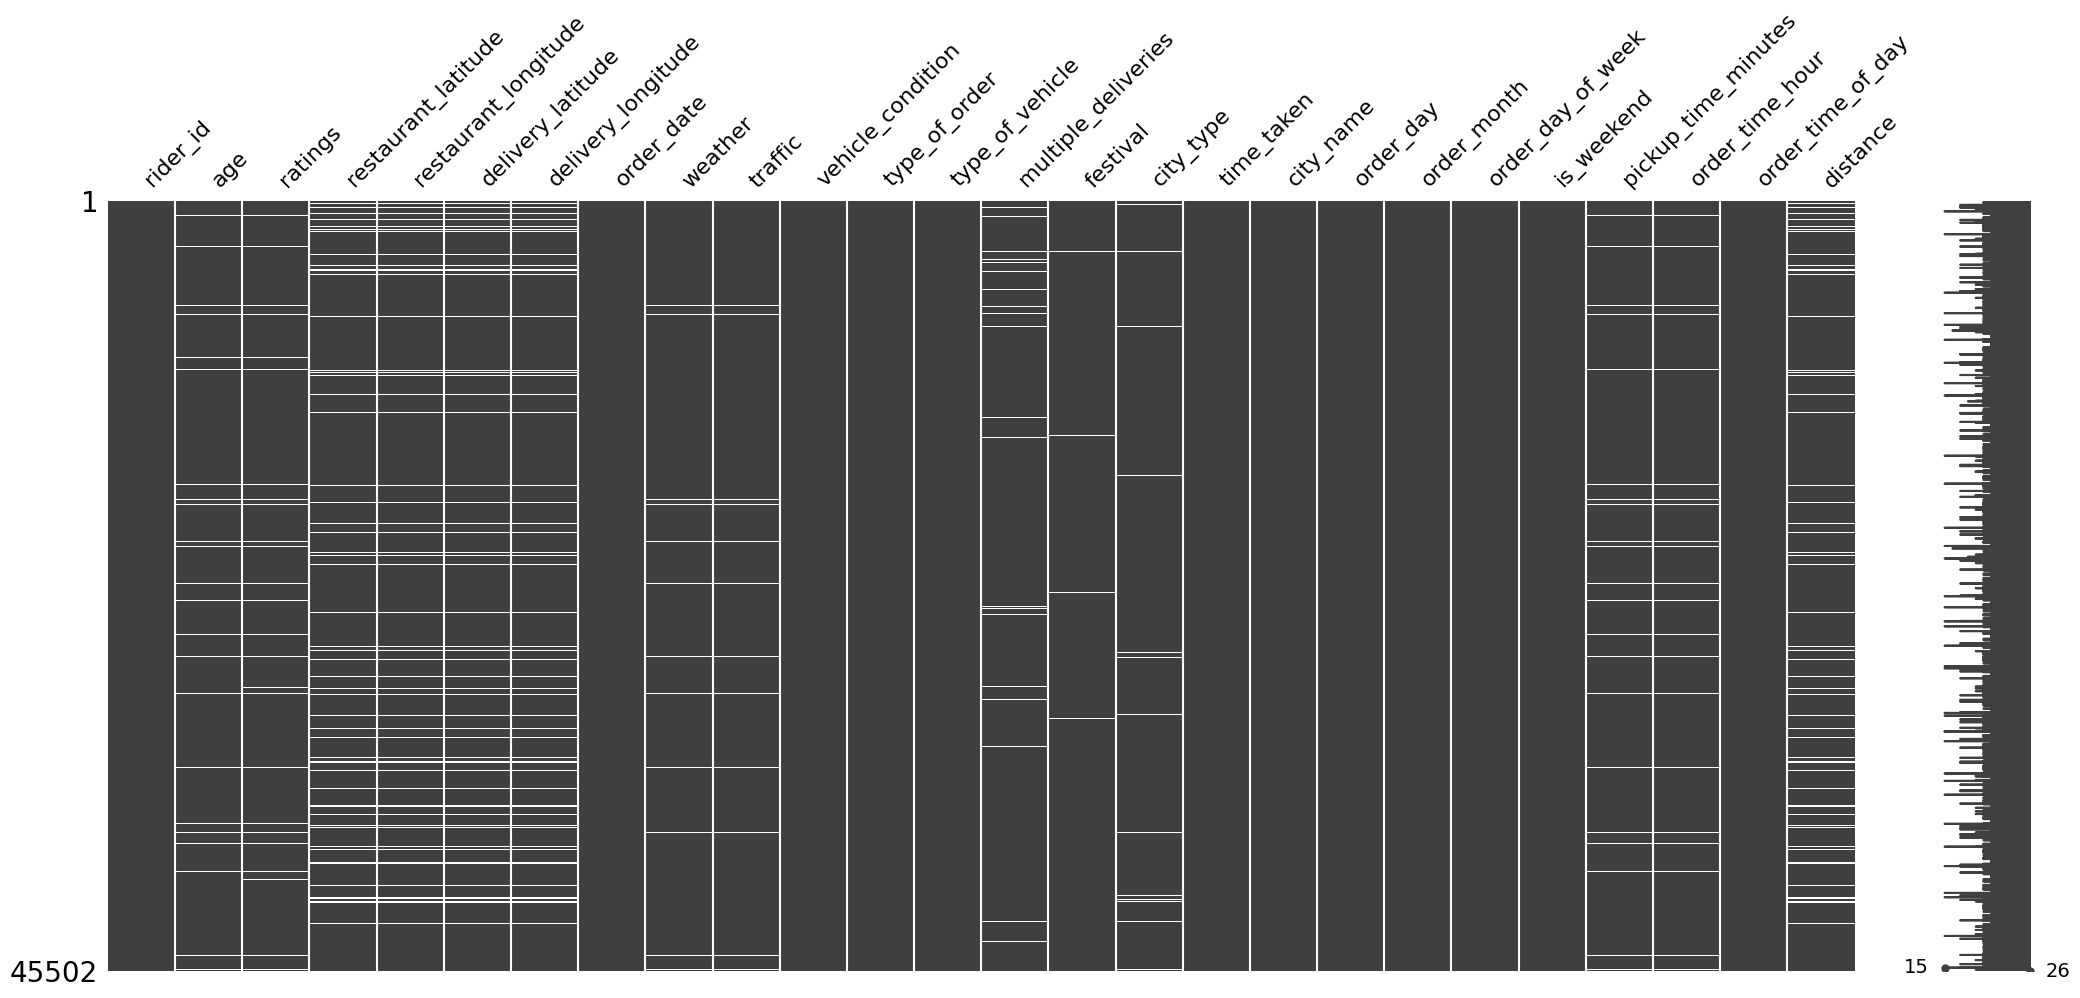

In [12]:
msno.matrix(df_final)

### Corr

<Axes: >

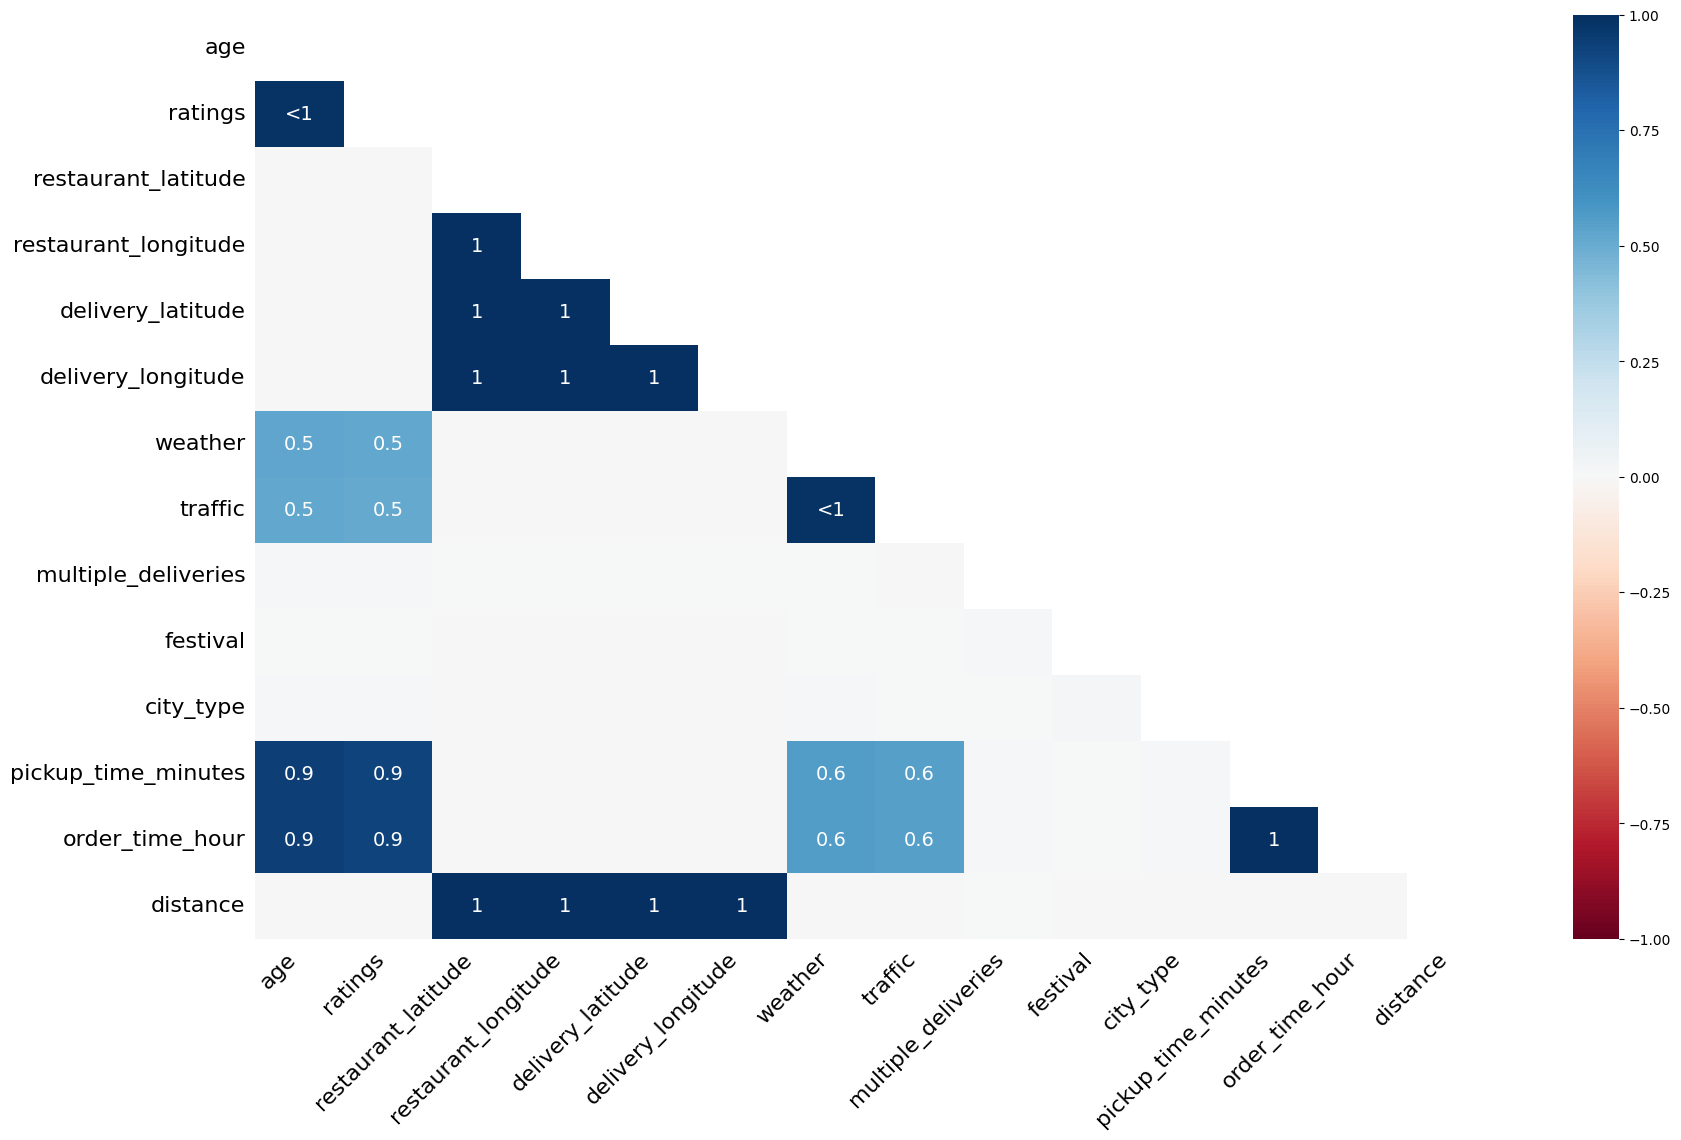

In [13]:
msno.heatmap(df_final)

### Dendrogram

<Axes: >

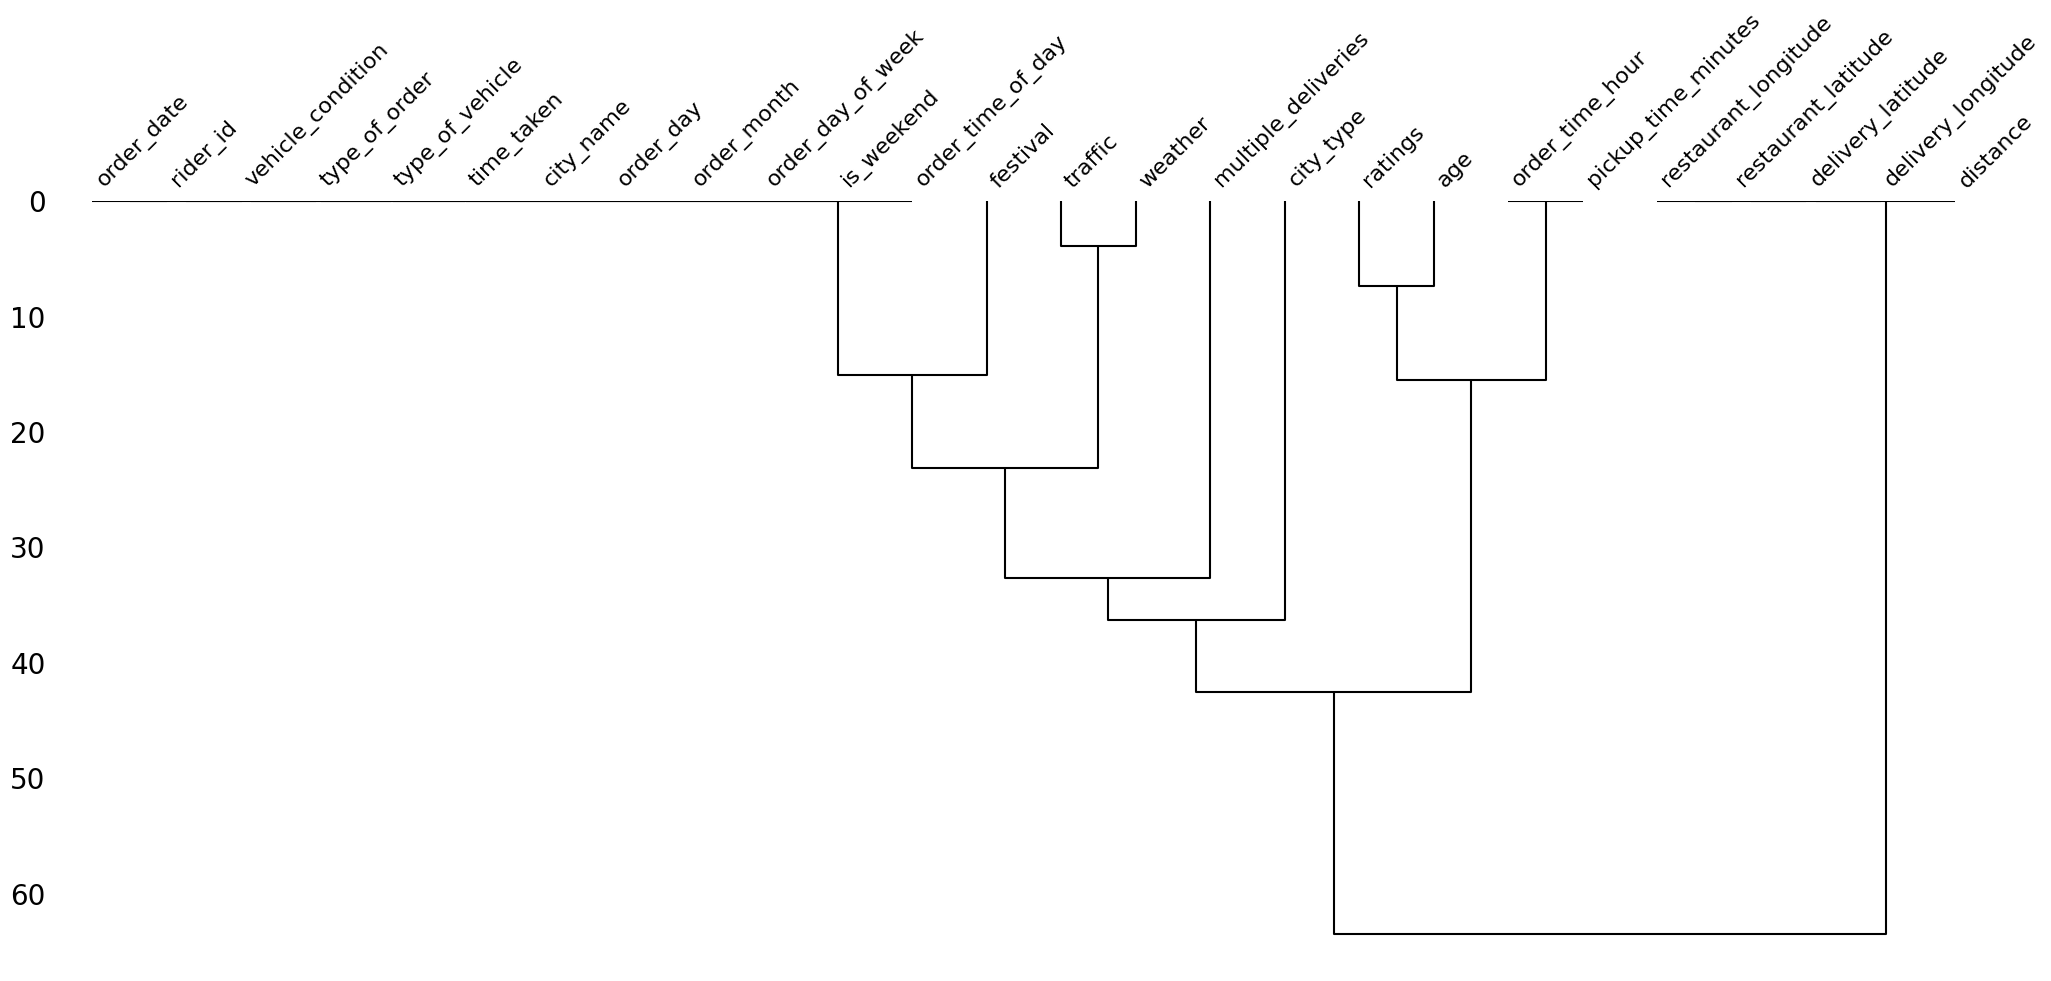

In [14]:
msno.dendrogram(df_final)

# Helper Functions to perform analysis

In [15]:
def numerical_analysis(dataframe, column_name, cat_col=None, bins="auto"):
    """
        Univariate analysis of numerical column
        Plots the kdeplot, boxplot and histogram
    """
    # create the figure
    fig = plt.figure(figsize=(15,10))
    # generate the layout
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    # set subplots
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    # plot the kdeplot
    sns.kdeplot(data=dataframe, x=column_name, hue=cat_col, ax=ax1)
    # plot the boxplot
    sns.boxplot(data=dataframe, x=column_name, hue=cat_col, ax=ax2)
    # plot the histogram
    sns.histplot(data=dataframe, x=column_name, bins=bins, hue=cat_col, kde=True, ax=ax3)
    plt.tight_layout()
    plt.show()


def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    """
        Bivariate analysis of categorical and numerical columns
        Plots the barplot, boxplot, violin plot and strip plot
    """
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[1])
    plt.tight_layout()
    plt.show()


def categorical_analysis(dataframe, column_name):
    """
        Univariate analysis of categorical column
        Plots the countplot
    """
    # print the values counts of categories
    display(
        pd.DataFrame({
            "Count": (
                dataframe[column_name]
                .value_counts()),
            "Percentage": (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype("str")
                .add("%")
                )
        })
    )
    print("*" * 50)
    # get unique categories
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()


def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    """
        Multivariate analysis of one numerical and two categorical columns
        Plots the barplot, boxplot, violin plot and strip plot
    """
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, gap=0.1, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, gap=0.1,
                   y=num_column,hue=cat_column_2, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1,
                  y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
    plt.tight_layout()
    plt.show()


def chi_2_test(dataframe, col1, col2, alpha= 0.05):
    """
        Hypothesis testing (Chi-Squared Test) for association between two categorical columns
    """
    data = (
        dataframe.loc[:, [col1, col2]]
        .dropna()
    )
    # create contingency table
    contingency_table = pd.crosstab(data[col1], data[col2])
    # perform chi-squared test
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant association between {col1} and {col2}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant association between {col1} and {col2}.")


def anova_test(dataframe, num_col, cat_col, alpha=0.05):
    """
        Hypothesis testing (ANOVA Test) for association between a numerical and a categorical column
    """
    data = (
        dataframe.loc[:, [num_col, cat_col]]
        .dropna()
    )
    cat_group = data.groupby(cat_col)
    groups = [group[num_col].values for _, group in cat_group]
    f_stat, p_val = f_oneway(*groups)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. There is a significant relationship between {num_col} and {cat_col}.")
    else:
        print(f"Fail to reject the null hypothesis. There is no significant relationship between {num_col} and {cat_col}.")


def test_for_normality(dataframe, column_name, alpha=0.05):
    """
        Normality test (Jarque Bera Test) between a numerical and target columns
    """
    data = dataframe[column_name]
    print("Jarque Bera Test for Normality")
    _, p_val = jarque_bera(data)
    print(p_val)
    if p_val <= alpha:
        print(f"Reject the null hypothesis. The data is not normally distributed.")
    else:
        print(f"Fail to reject the null hypothesis. The data is normally distributed.",end="\n\n")

Normality test
- Jarque Bera Test : for large dataset (more than 2000 rows)
- Shapiro Wilk Test : work on small (less than 2000 rows) dataset
- Omnibus Test : work on small dataset
- Anderson Darling Test : 
- Kolmogorov Smirnov Test : 

# Column Wise Analysis

In [16]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='str')

## Time Taken (Target)

>**Always starting EDA with the target column**

In [17]:
# data type of column

df_final['time_taken'].dtype

dtype('int64')

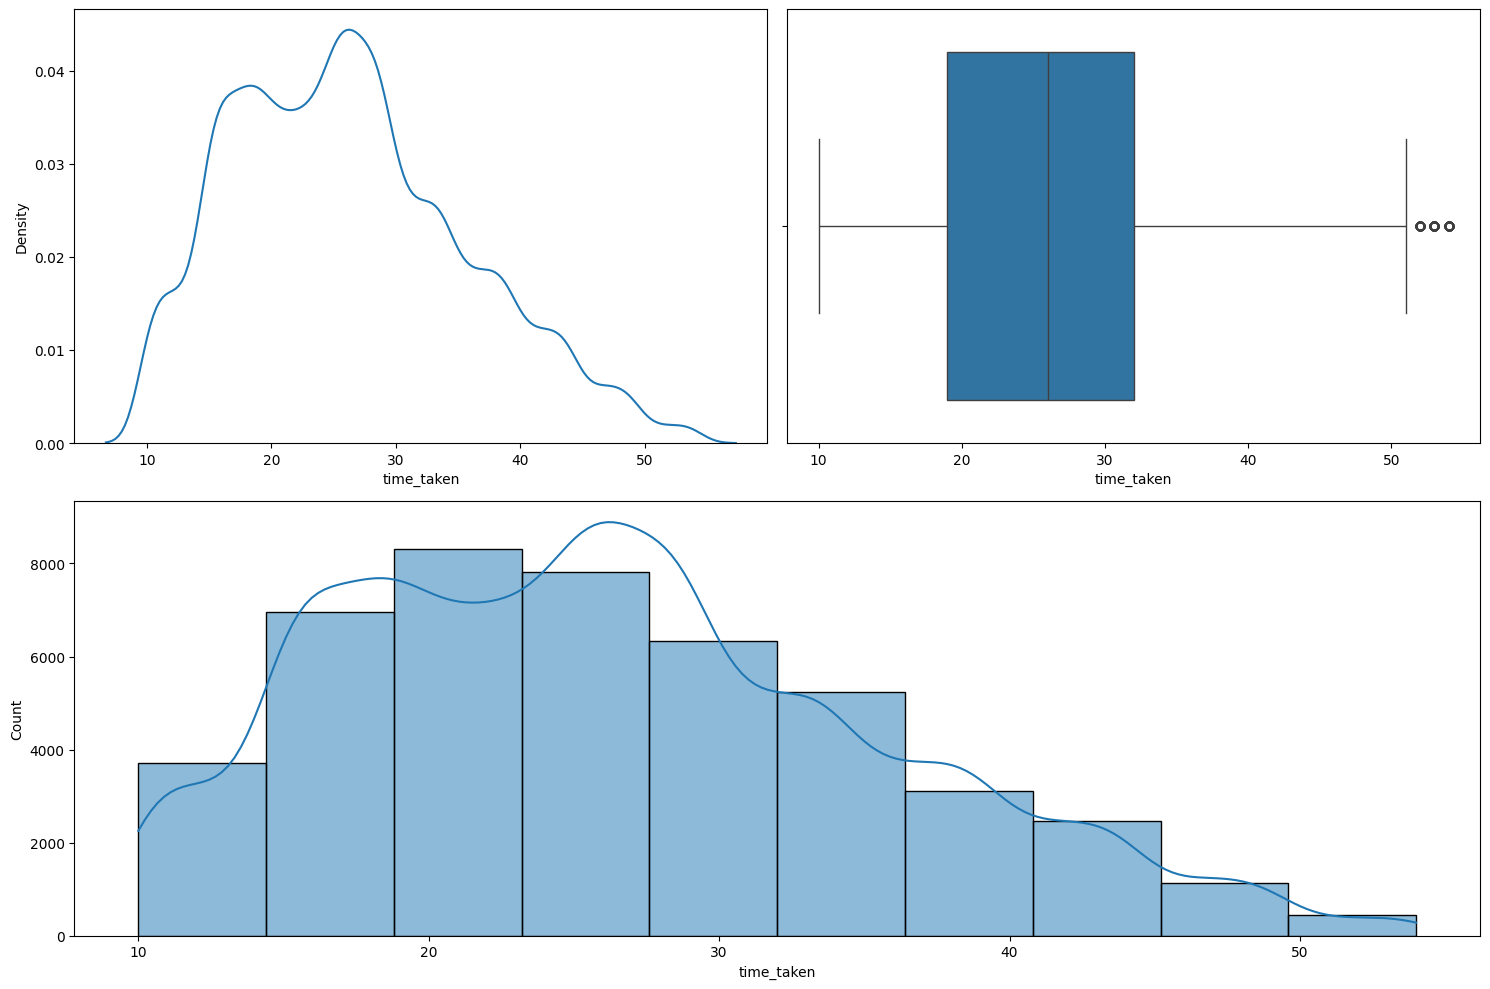

In [18]:
# numerical analysis

numerical_analysis(df_final, 'time_taken', bins=10)

**Observations**:

1. The target column is not fully continuous in nature.
2. The target column shows dual modality with two peaks- One peak around the 17-18 mark and other around 26-27 mark.
4. The target column has some extreme points which can be thought of as outliers but they are just extreme and rare, not outliers. 50 min time is possible for delivery in certain rare cases.

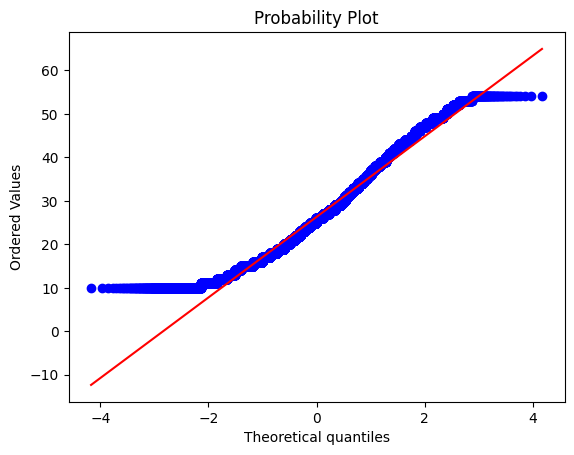

In [19]:
# plot QQ plot for the target

probplot(df_final['time_taken'], plot=plt)
plt.show()

**Observations:**
- from -2 to 2, all the Observed values (sample) follow the theoretical normal distribution (popuation)
- tails above 2 and below -2, all the observed values deviate from theoretical normal distribution which is fine

In [20]:
# tests for normailty

test_for_normality(df_final, 'time_taken')

Jarque Bera Test for Normality
0.0
Reject the null hypothesis. The data is not normally distributed.


In [21]:
# check out the rows where data is acting as outlier

target_25_per, target_75_per = np.percentile(df_final['time_taken'], [25, 75])
iqr = target_75_per - target_25_per

upper_bound = target_75_per + (1.5 * iqr)

df_final.loc[(df_final['time_taken'] > upper_bound), "traffic"].value_counts()

traffic
jam     241
high     24
Name: count, dtype: int64

**Observations:**
- When traffic conditions are jam or high then it takes more time_taken to deliver the food

In [22]:
df_final.loc[(df_final['time_taken'] > upper_bound), "weather"].value_counts()
# Don't show any pattern

weather
fog           57
sunny         51
cloudy        44
windy         44
stormy        37
sandstorms    32
Name: count, dtype: int64

In [23]:
# average distances

avg_distance = df_final.loc[:,"distance"].mean()
avg_distance_extreme = df_final.loc[(df_final['time_taken'] > upper_bound),"distance"].mean()

print(avg_distance, avg_distance_extreme)

9.71929632319958 13.29215081388658


**Observations:**
- average distance is higher for extrem time_taken values

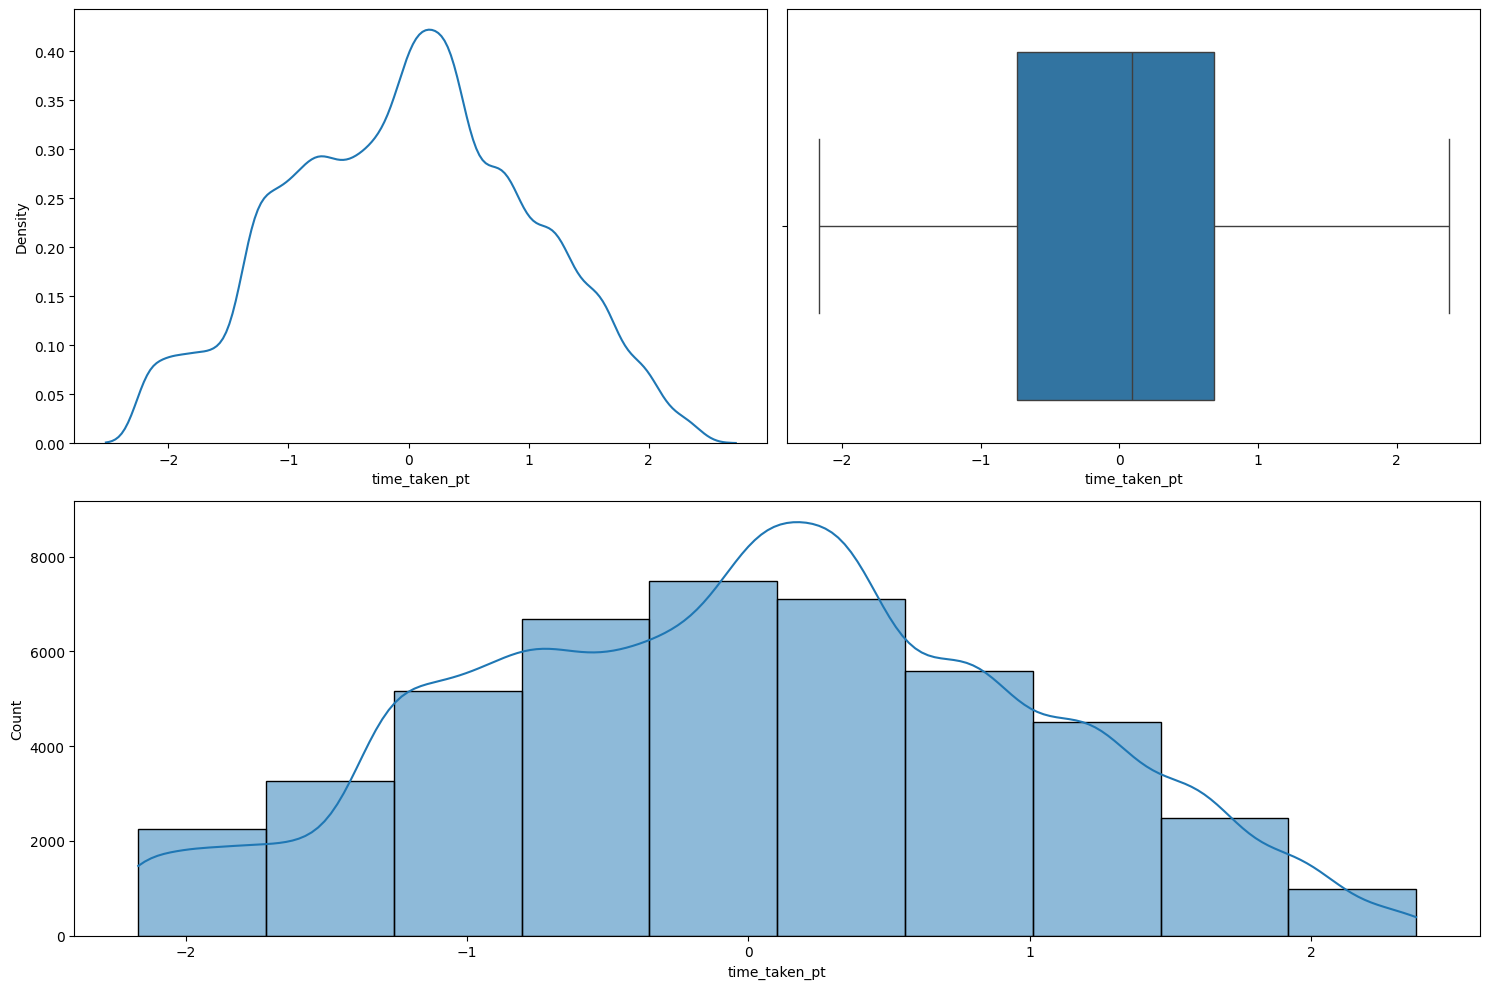

In [24]:
# fix target column by transformation to normal distribution using Yeo-Johnson technique

from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
df_final['time_taken_pt'] = pt.fit_transform(df_final[['time_taken']])
numerical_analysis(df_final, "time_taken_pt", bins=10)

- Single peak from two peaks is done
- outliers are gone
- looks more like normal distribution now

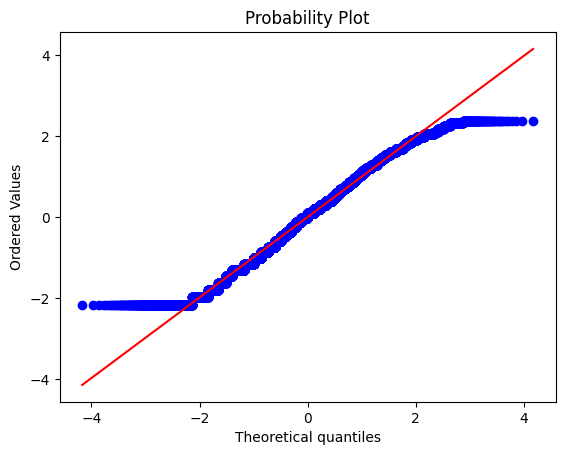

In [25]:
# plot QQ plot for the target after transformation

probplot(df_final['time_taken_pt'], plot=plt)
plt.show()

- Minor emprovement is visible

## Rider_ID

Keep rider_id as it might be used for data imputation

In [26]:
# datatype of rider id

df_final['rider_id'].dtype

<StringDtype(storage='python', na_value=nan)>

Assuming ratings is for the rider, not for the delivery, so we are using `["rider_id", "age", "ratings"]`

if ratings for the delivery, then we have to perform below analysis on `["rider_id", "age"]`

In [27]:
df_final[["rider_id", "age", "ratings"]]

,rider_id,age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45497,JAPRES04DEL01,30.0,4.8
45498,AGRRES16DEL01,21.0,4.6
45499,CHENRES08DEL03,30.0,4.9
45500,COIMBRES11DEL01,20.0,4.7


In [28]:
# grouping data on the basis of rider_id

rider_id_group = df_final[["rider_id", "age", "ratings"]].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
7738,AGRRES010DEL01,21.0,4.7
4554,AGRRES010DEL01,38.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
9792,VADRES20DEL03,30.0,4.6
9753,VADRES20DEL03,38.0,4.8
5094,VADRES20DEL03,35.0,4.9


In [29]:
# check for duplicates

df_final[["rider_id", "age", "ratings"]].dropna().duplicated(keep=False).sum()

np.int64(10155)

In [30]:
# filter the duplicates

(
    df_final
    .loc[(df_final[["rider_id", "age", "ratings"]].duplicated(keep=False)), ["rider_id", "age", "ratings"]]
    .dropna()
    .sort_values(["rider_id"])
)

,rider_id,age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
28473,AGRRES03DEL03,30.0,4.7
26275,AGRRES03DEL03,30.0,4.7
36131,AGRRES06DEL02,36.0,4.9
...,...,...,...
12742,VADRES20DEL02,28.0,4.5
5094,VADRES20DEL03,35.0,4.9
17963,VADRES20DEL03,35.0,4.9
21957,VADRES20DEL03,37.0,4.9


**Not Useful for our analysis** as there are multiple entries for the same rider_id with different age and ratings values. So, we cannot impute the missing values based on rider_id. We can drop this column as it is not useful for our analysis.

## Age

In [31]:
# data type of age column

df_final['age'].dtype

dtype('float64')

In [32]:
# statistical summary

df_final['age'].describe()

count    43648.000000
mean        29.555008
std          5.761482
min         20.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         39.000000
Name: age, dtype: float64

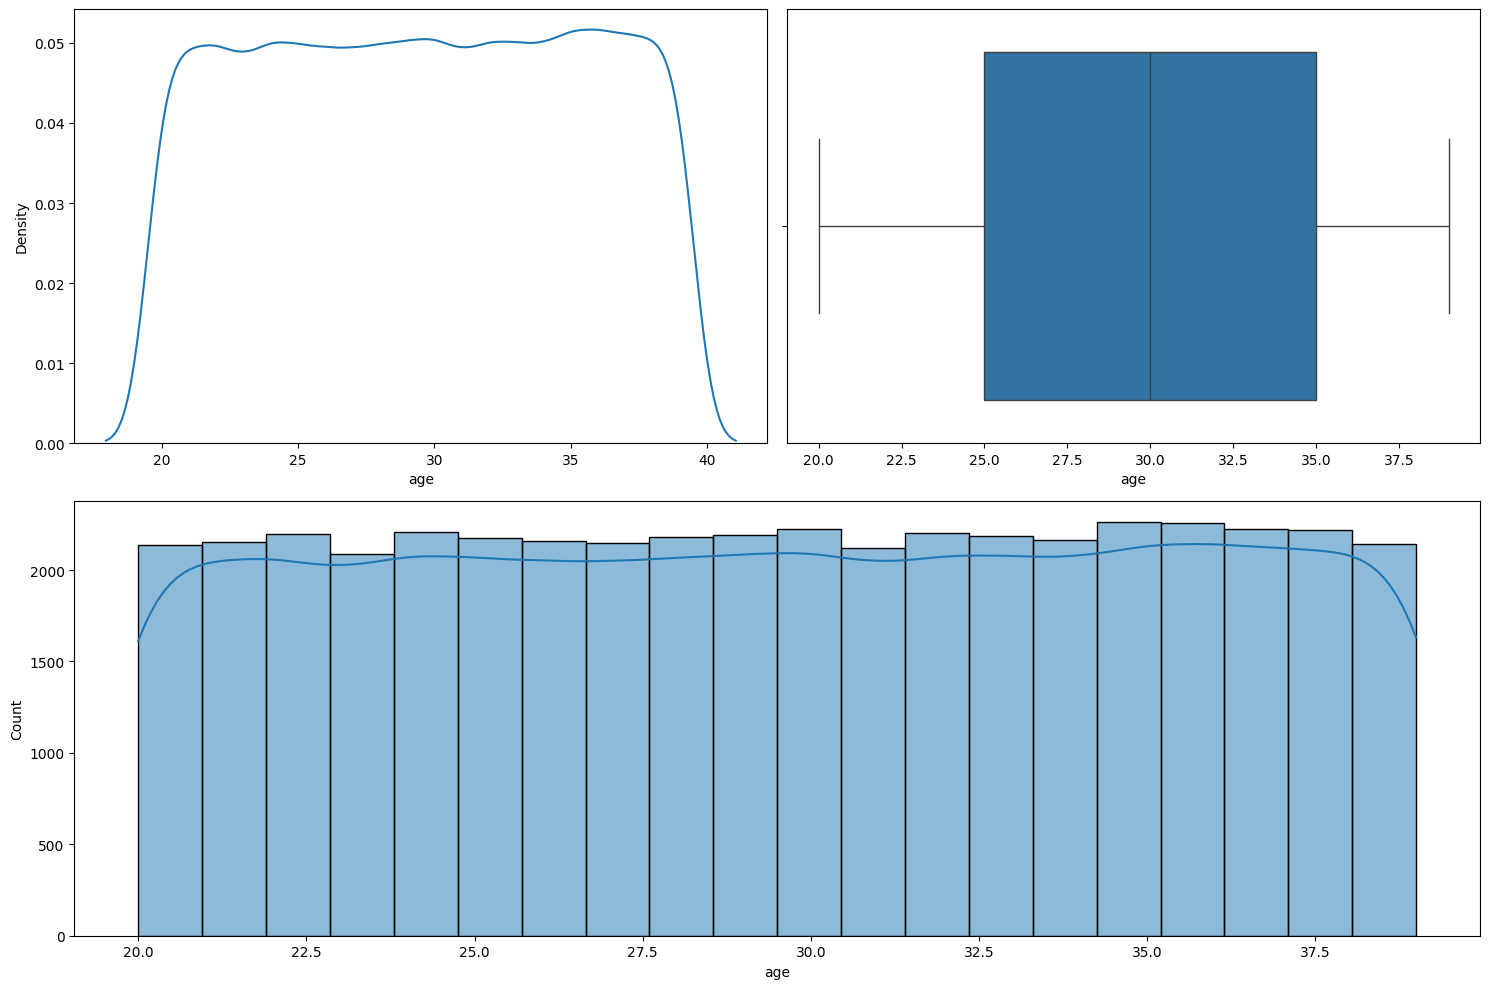

In [33]:
# numerical analysis for age

numerical_analysis(df_final, 'age',bins=20)

- age is uniformly distributed between 20 to 40
- there is no outliers in the age column

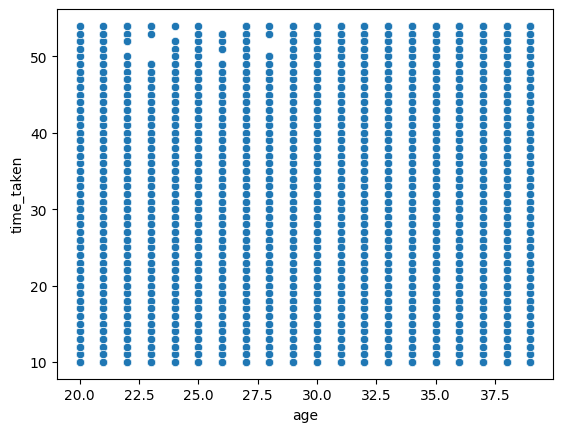

In [34]:
# relationship between target and age

sns.scatterplot(data=df_final, x='age', y='time_taken')
plt.show()

- **Age of the rider does not show any impact on timetaken to deliver**
- also shows us that age column is descreate and not continuous

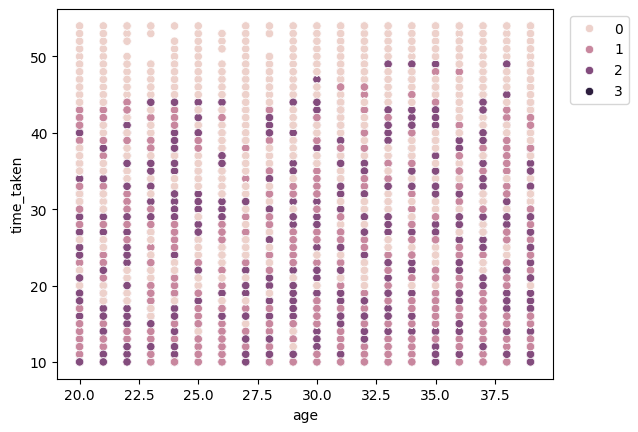

In [35]:
sns.scatterplot(data=df_final, x='age', y='time_taken', hue="vehicle_condition")
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)
plt.show()

- for longer delivery time, 0 vehicle_condition is mostly used

<Axes: xlabel='type_of_vehicle', ylabel='age'>

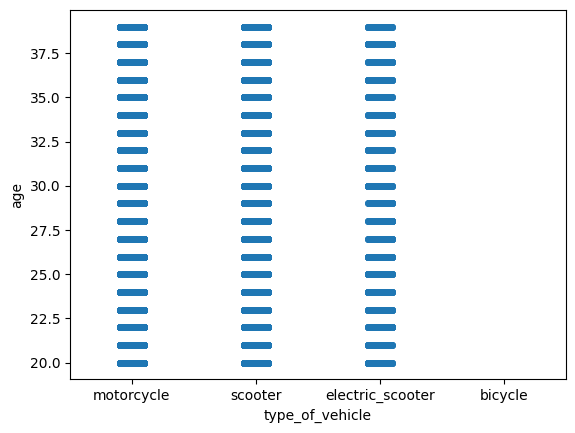

In [36]:
# preferences of vehicle type based on age

sns.stripplot(df_final, x='type_of_vehicle', y='age')

In [37]:
len(df_final[df_final['type_of_vehicle'] == 'bicycle'])

53

In [38]:
df_final[df_final['type_of_vehicle'] == 'bicycle']['age'].isnull().sum()

np.int64(53)

- no impact on type_of_vehicle on the basis of age of the rider
- for bicycle, there is no record because all age values are NaN in the data

## Ratings

In [39]:
# data type of rating column

df_final['ratings'].dtype

dtype('float64')

In [40]:
# statistical summary

df_final['ratings'].describe()

count    43594.000000
mean         4.635287
std          0.313827
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: ratings, dtype: float64

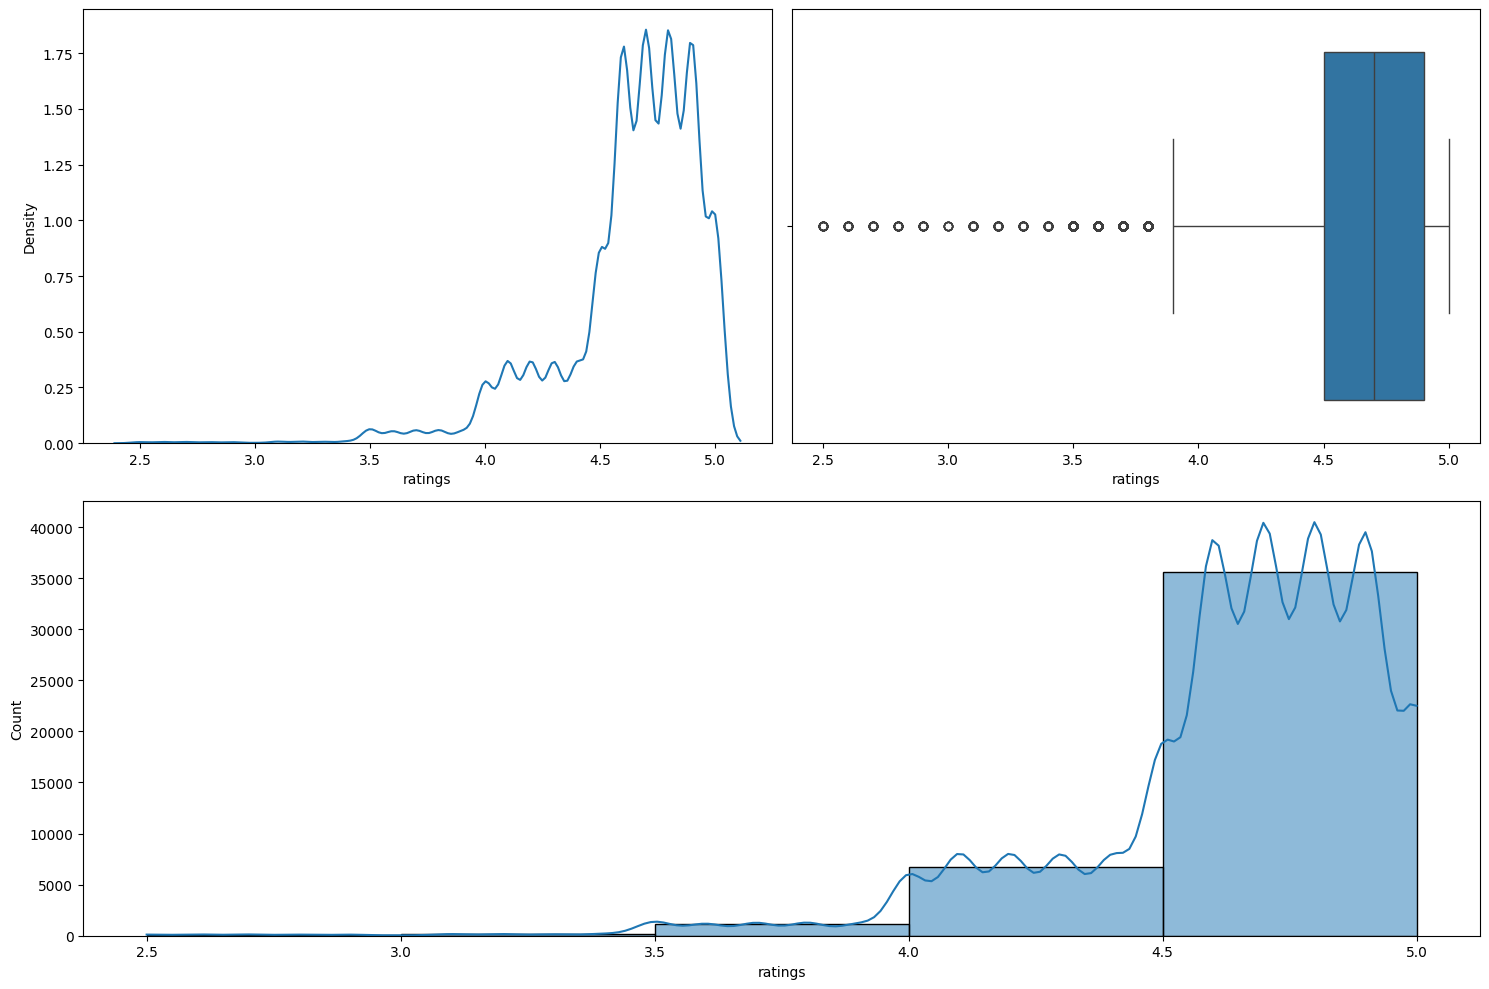

In [41]:
# numerical analysis

numerical_analysis(df_final, 'ratings', bins=5)

- ratings is left skewed
- there are some geneuine outliers between 2.5 to 4 ratings
- very less riders have ratings less than 3.5

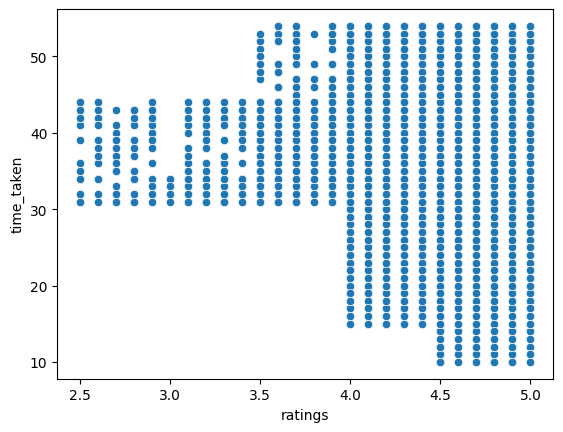

In [42]:
# does ratings affect delivery time

sns.scatterplot(data=df_final, x='ratings', y='time_taken')
plt.show()

- **It seems like riders with more ratings get more orders** or **Higher ratings equates to more work and more income opportunities**
- rider with high ratings only got very long and very short delivery

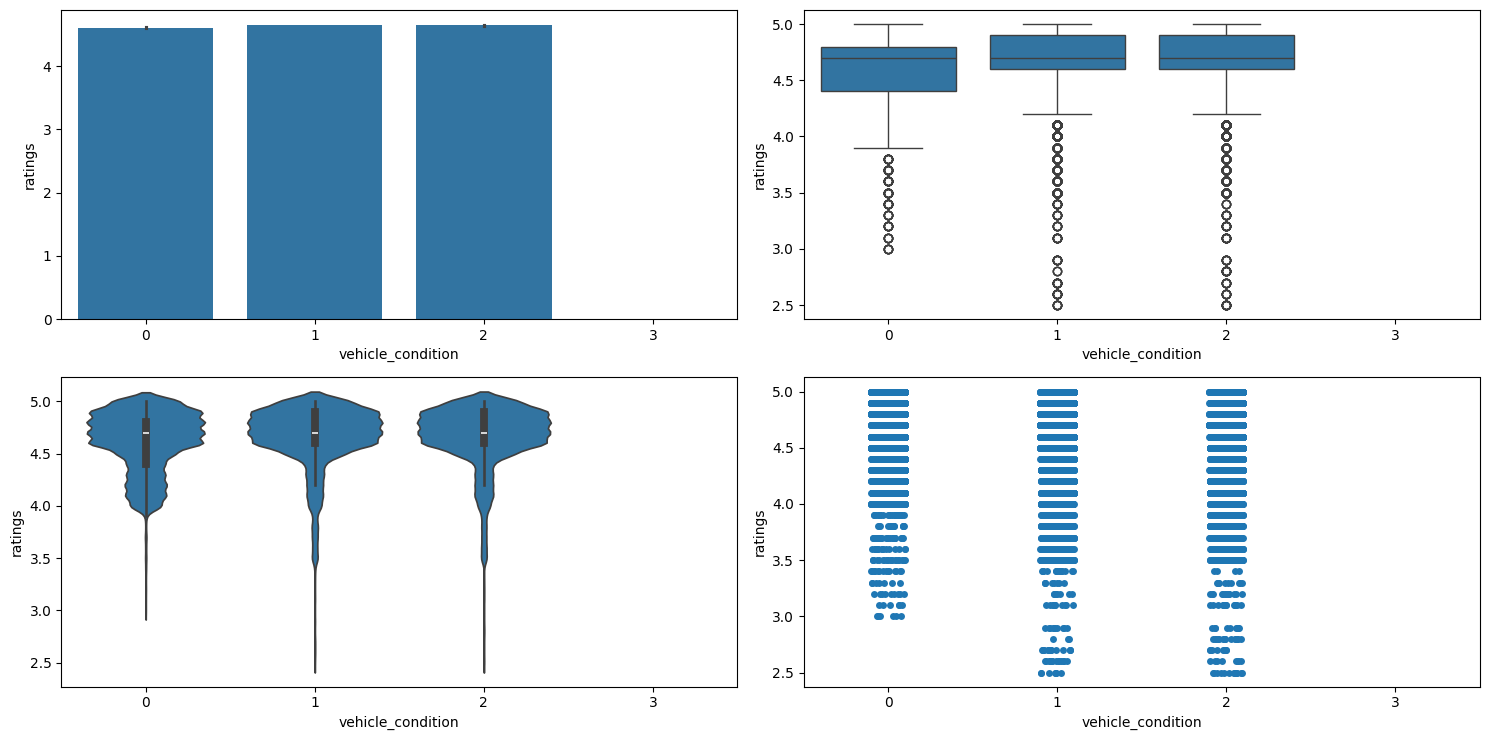

In [43]:
# does ratings get affected by vehicle type

numerical_categorical_analysis(df_final, 'vehicle_condition', 'ratings')

**Yes they do**

- The more worst the vehicle condition is, the more lower the rating gets.
- The category 3 has no data means there are NaN values. This simply means that customers avoid rating their riders even rating of 1 when the vehicle condition is worst.

In [44]:
(
    df_final[["ratings", "vehicle_condition"]]
    .loc[df_final["vehicle_condition"]==3, "ratings"]
    .value_counts(dropna=False)
)

ratings
NaN    429
Name: count, dtype: int64

- All ratings of vehicle condition 3 are NaN

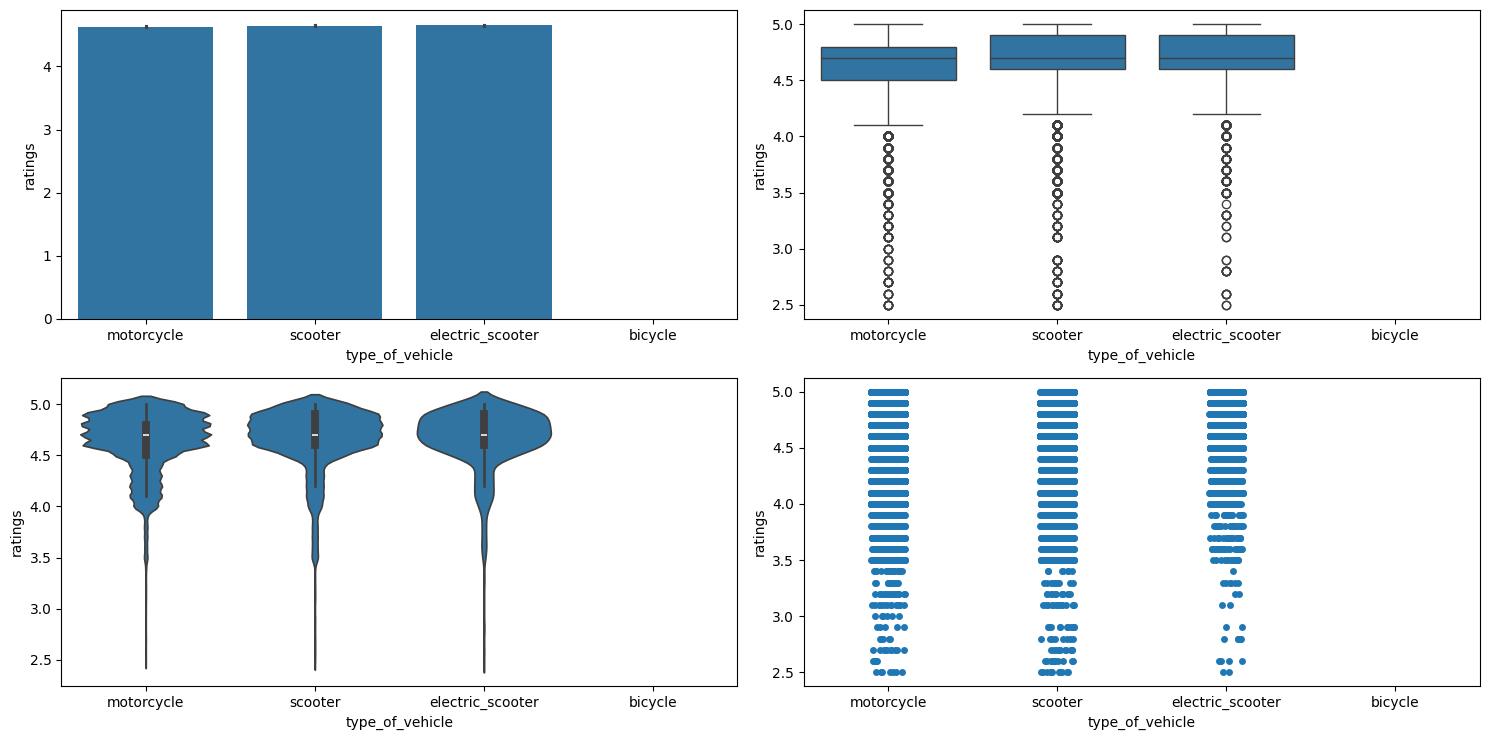

In [45]:
# does type of vehicle affects ratings

numerical_categorical_analysis(df_final, 'type_of_vehicle', 'ratings')

- electric_scooter slightly got less lower ratings than the other type_of_vehicle

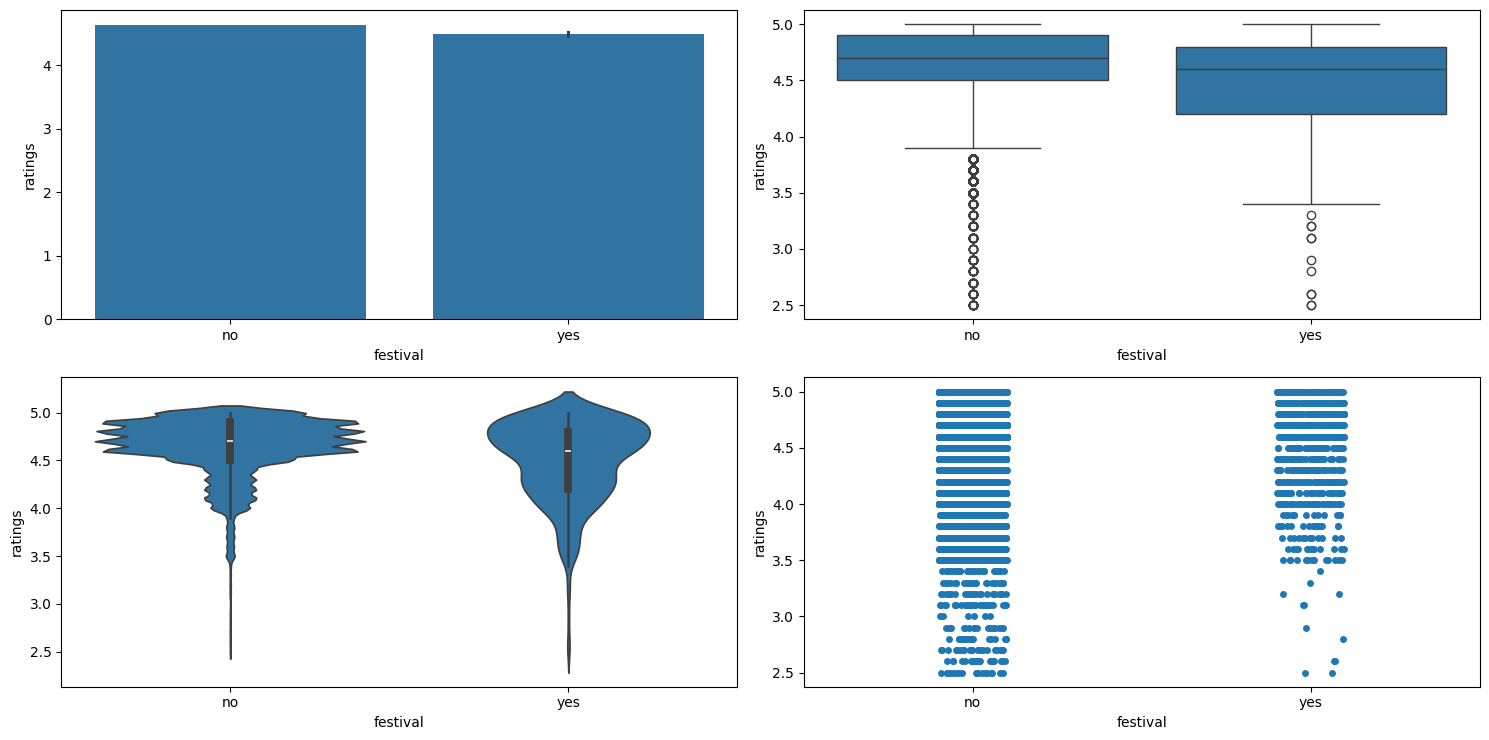

In [46]:
# festvals and rider ratings

numerical_categorical_analysis(df_final, 'festival', 'ratings')

- slightly less number ratings in festival season than non festival season due to high delivery_time or customers remains busy in festival season and avoid rating their riders
- rider got higher ratings during festival season than non festival season because they are more happy with the service during festival season than non festival season

## Location Based Features

In [47]:
df_final.columns[3:7].tolist() + ["city_name"]

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [ ]:
# location subset

location_subset = df_final.loc[:,df_final.columns[3:7].tolist() + ["city_name"]]
location_subset.dropna(inplace=True)
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [49]:
location_subset.dtypes

restaurant_latitude     float64
restaurant_longitude    float64
delivery_latitude       float64
delivery_longitude      float64
city_name                   str
dtype: object

In [129]:
# plot deliveries on map

delivery_df = pd.DataFrame({
    'latitude': location_subset['delivery_latitude'],
    'longitude': location_subset['delivery_longitude'],
    "city_name": location_subset["city_name"]
})

# Create a map using Plotly's scatter_mapbox
fig = px.scatter_map(
    delivery_df,
    lat='latitude',
    lon='longitude',
    title="Delivery Points",
    hover_name="city_name"
)

# Update the layout for the map of India
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_center={"lat": 20.5937, "lon": 78.9629},  # Centered over India
    mapbox_zoom=3,
)
fig.show()

- On varifying the city_name on the above map, we can say that the city_name is correct
- We can notice that these deliveries are mostly done in few major cities of India

## Order Date

In [53]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'time_taken_pt'],
      dtype='str')

In [54]:
df_final.filter(like="order")

,order_date,type_of_order,order_day,order_month,order_day_of_week,order_time_hour,order_time_of_day
0,2022-03-19,snack,19,3,saturday,11.0,morning
1,2022-03-25,snack,25,3,friday,19.0,evening
2,2022-03-19,drinks,19,3,saturday,8.0,morning
3,2022-04-05,buffet,5,4,tuesday,18.0,evening
4,2022-03-26,snack,26,3,saturday,13.0,afternoon
...,...,...,...,...,...,...,...
45497,2022-03-24,meal,24,3,thursday,11.0,morning
45498,2022-02-16,buffet,16,2,wednesday,19.0,evening
45499,2022-03-11,drinks,11,3,friday,23.0,night
45500,2022-03-07,snack,7,3,monday,13.0,afternoon


In [ ]:
# order date columns

order_date_subset = df_final.loc[:, ["order_date", "order_day", "order_month", "order_day_of_week", "is_weekend", "festival"]]
order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,saturday,1,no
1,2022-03-25,25,3,friday,0,no
2,2022-03-19,19,3,saturday,1,no
3,2022-04-05,5,4,tuesday,0,no
4,2022-03-26,26,3,saturday,1,no
...,...,...,...,...,...,...
45497,2022-03-24,24,3,thursday,0,no
45498,2022-02-16,16,2,wednesday,0,no
45499,2022-03-11,11,3,friday,0,no
45500,2022-03-07,7,3,monday,0,no


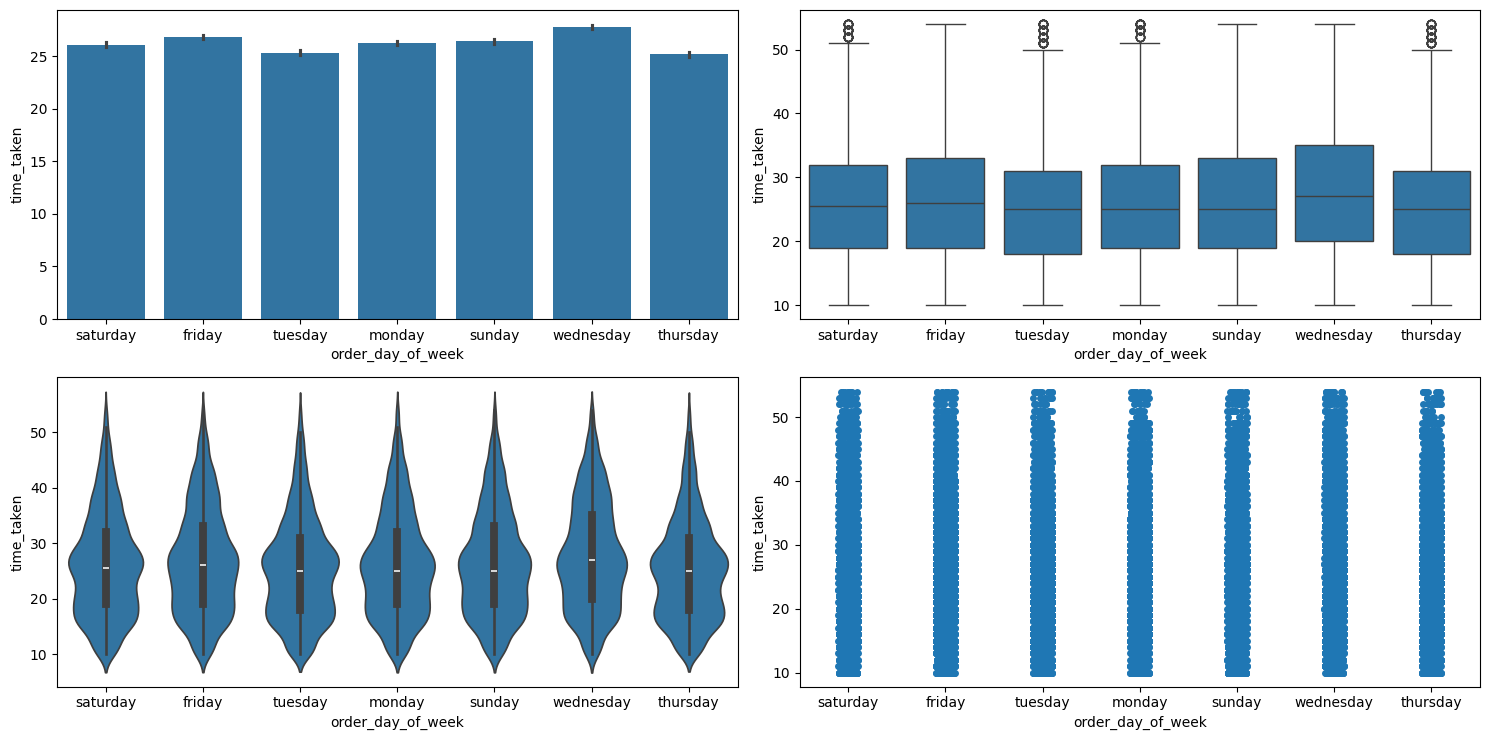

In [56]:
# analysis between day of week and target

numerical_categorical_analysis(df_final, "order_day_of_week", "time_taken")

- thursday and tuesday are the least time_taken
- while wednesday has the highest average time_taken

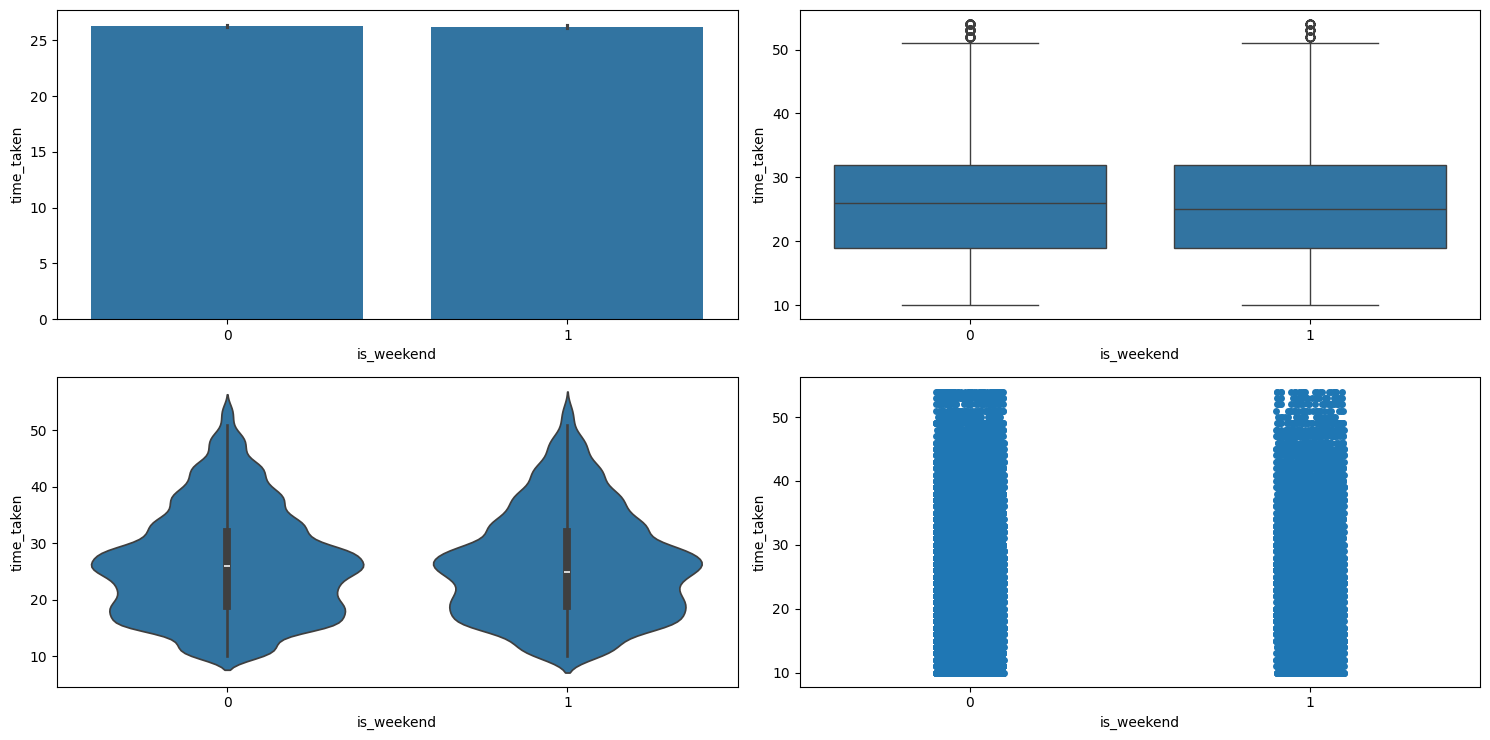

In [57]:
# does having a weekend affects target

numerical_categorical_analysis(df_final, "is_weekend", "time_taken")

- is_weekend has no impact on time_taken to deliver the food

In [58]:
# do weekends have an impact on traffic

chi_2_test(df_final, "is_weekend", "traffic")

0.6845961396354259
Fail to reject the null hypothesis. There is no significant association between is_weekend and traffic.


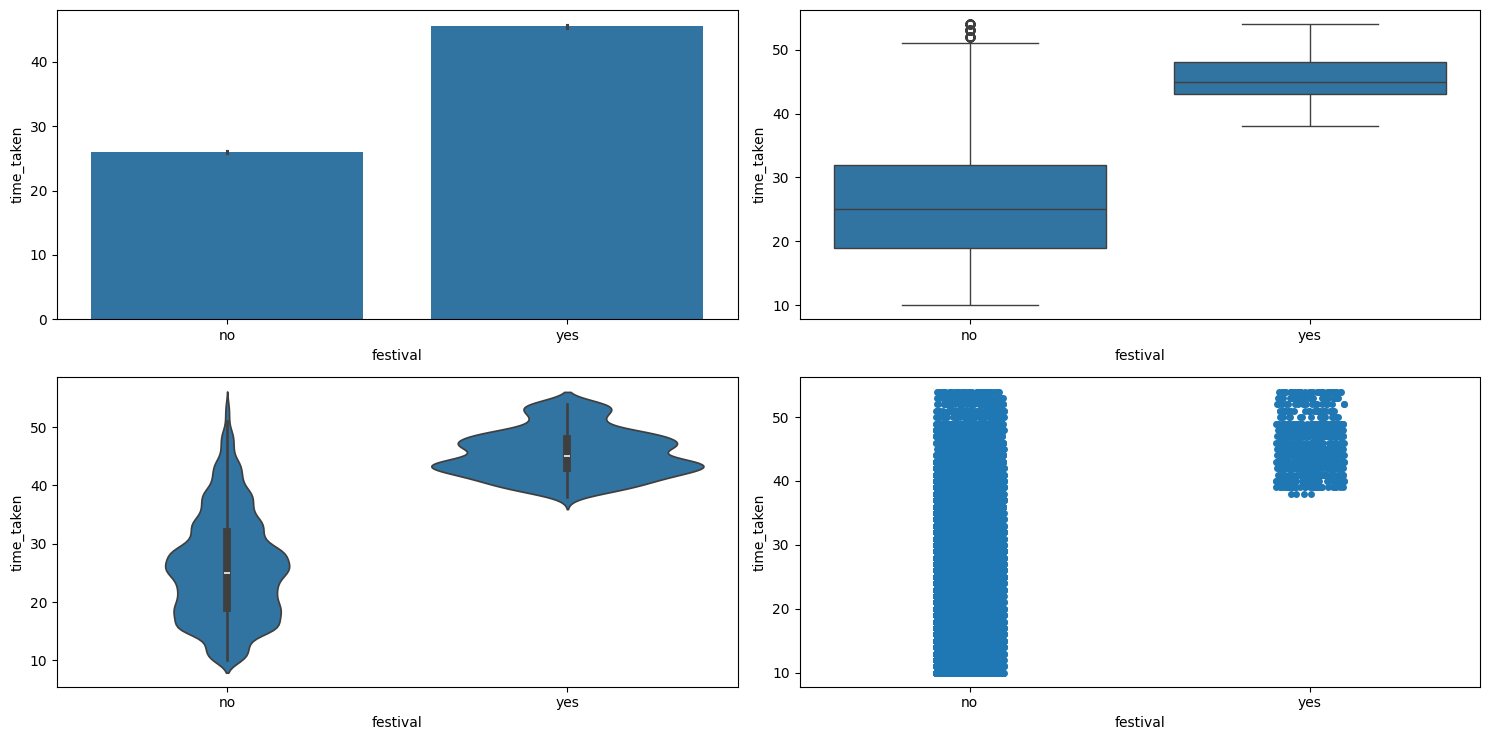

In [59]:
# festivals and target analysis

numerical_categorical_analysis(df_final, "festival", "time_taken")

**Observations**:
- The avg time it takes for delivery. time_taken varies when there is a festival.
- The range of delivery time is shorter when there is a festival with lesser variation, which means on a festival delivery times usually takes longer.

In [60]:
# do festival affect traffic

chi_2_test(df_final, "festival", "traffic")

1.1223471129146869e-153
Reject the null hypothesis. There is a significant association between festival and traffic.


The p value is very small which means it does affect traffic. This might means that festival directly don't affect time_taken but it affects traffic which in turn affects time_taken

In [ ]:
df_final.pivot_table(index="traffic", columns="festival", values="time_taken", aggfunc="mean")

festival,no,yes
traffic,,
high,27.010373,45.826087
jam,30.538039,46.093651
low,21.284332,42.020000
medium,26.550288,43.715385


- In general, festival season increases time_taken irrespective of traffic conditions.

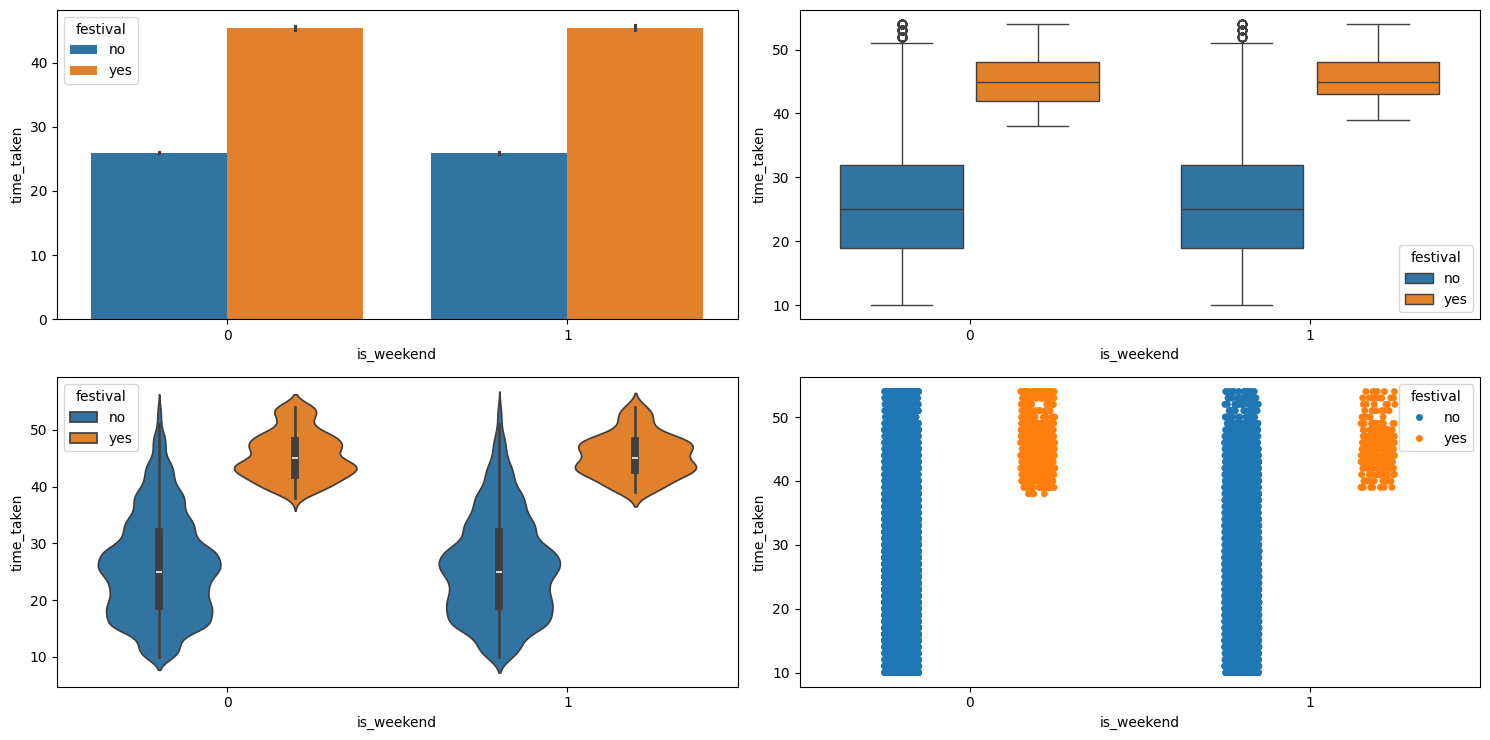

In [62]:
# does a weekend and a festival combined have an effect on delivery times

multivariate_analysis(df_final, "time_taken", "is_weekend", "festival")

- no impact of festival on weekend on time_taken

## Order Time

In [63]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'time_taken_pt'],
      dtype='str')

In [ ]:
# time related columns

time_subset = df_final.loc[:, ["order_time_hour", "order_time_of_day", "pickup_time_minutes"]]
time_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
45497,11.0,morning,10.0
45498,19.0,evening,15.0
45499,23.0,night,15.0
45500,13.0,afternoon,5.0


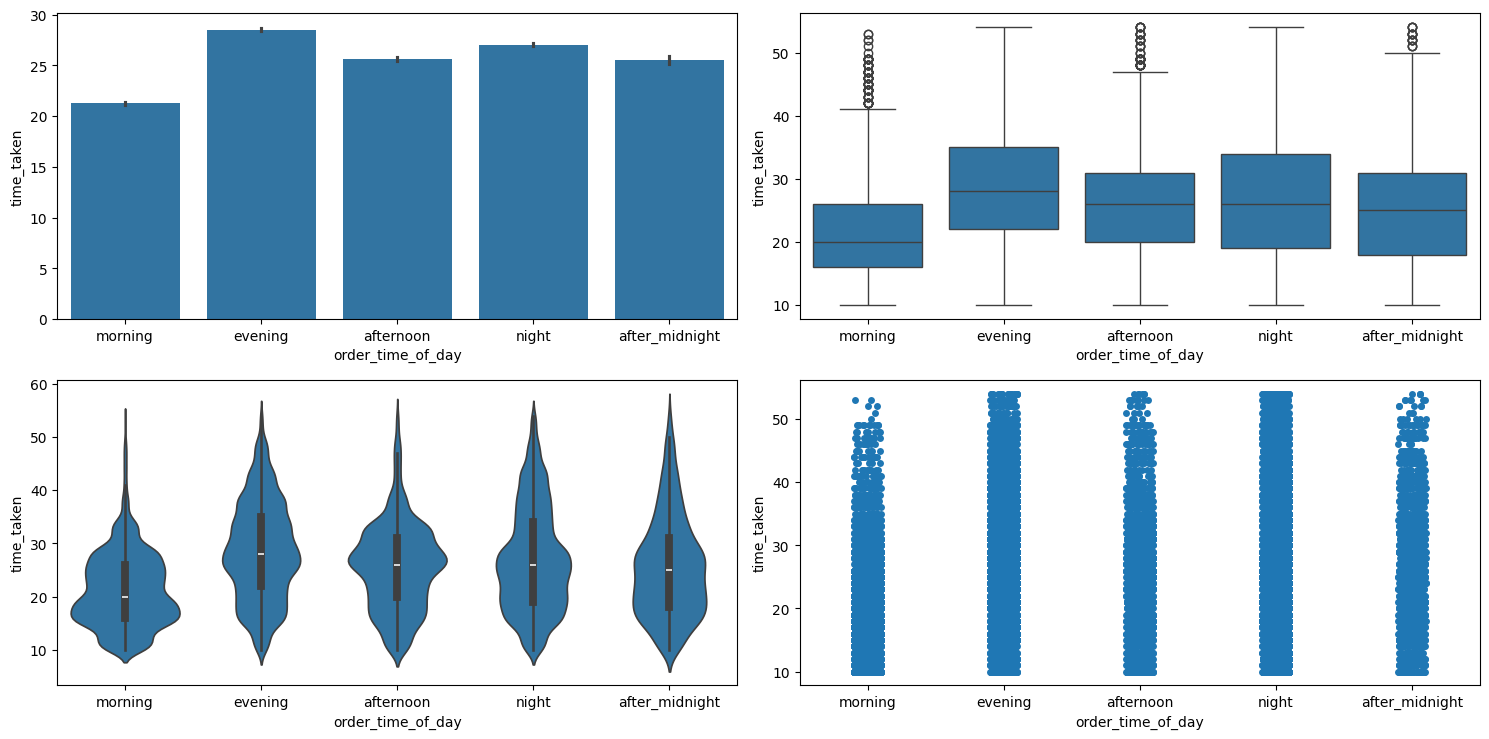

In [65]:
# does time of day affects delivery times

numerical_categorical_analysis(df_final, "order_time_of_day", "time_taken")

- time_taken is least in morning
- time_taken is highest in the night and evening time

In [66]:
# relationship between time of day and traffic

chi_2_test(df_final, "order_time_of_day", "traffic")

0.0
Reject the null hypothesis. There is a significant association between order_time_of_day and traffic.


In [67]:
# anova test

anova_test(df_final, "time_taken", "order_time_of_day")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and order_time_of_day.


In [68]:
# Top 5 times(hrs) of the day in which customers  order the most

df_final["order_time_hour"].value_counts().head(5)

order_time_hour
21.0    4686
19.0    4595
22.0    4576
20.0    4539
23.0    4511
Name: count, dtype: int64

- most orders are placed in the 19 to 23 hour of the day

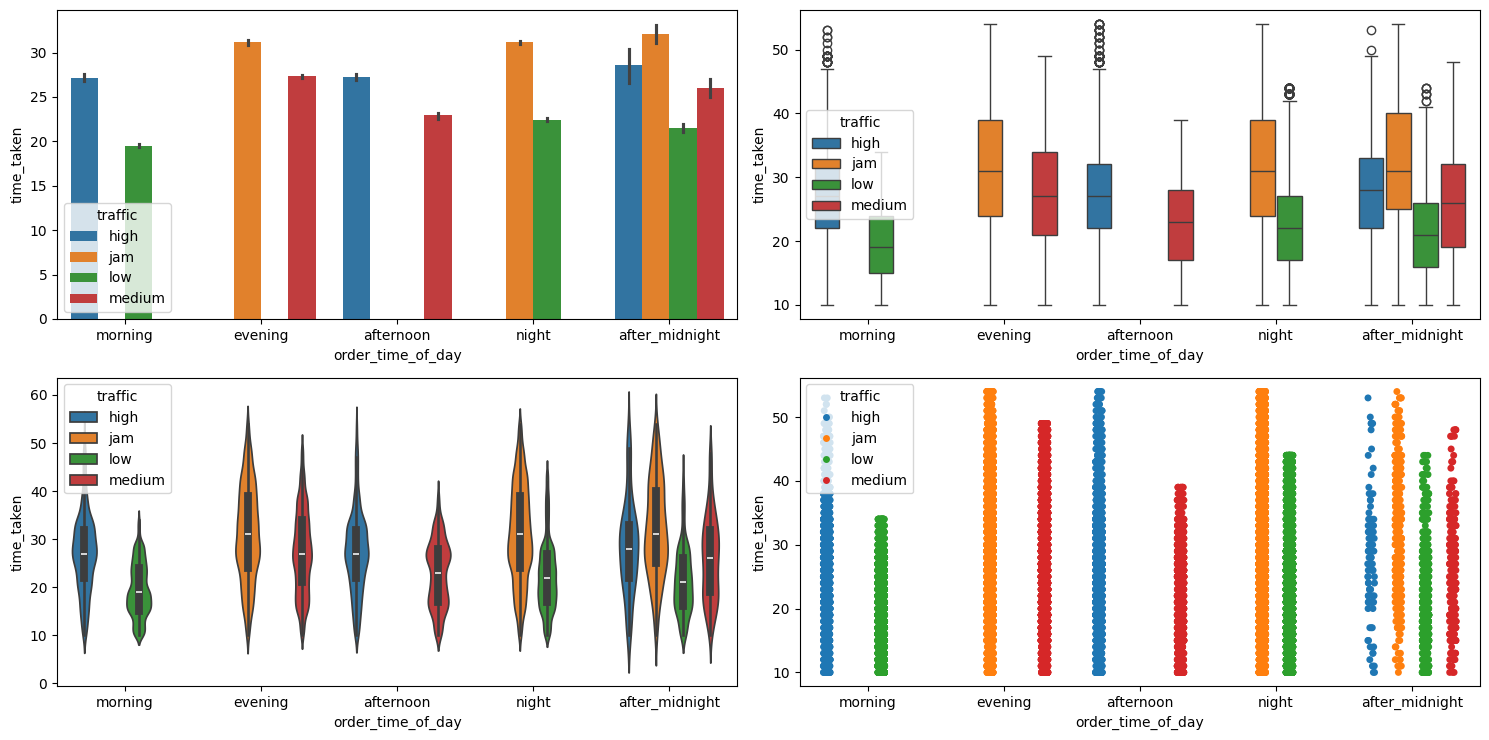

In [69]:
# can delivery time be affected by both time of day and traffic

multivariate_analysis(df_final, "time_taken", "order_time_of_day", "traffic")

- high traffic happens in morning, afternoon and after_midnight

,Count,Percentage
order_time_hour,,
21.0,4686,10.68%
19.0,4595,10.48%
22.0,4576,10.43%
20.0,4539,10.35%
23.0,4511,10.28%
18.0,4480,10.21%
17.0,4278,9.75%
10.0,1991,4.54%
11.0,1962,4.47%


**************************************************
The unique categories in order_time_hour column are [11.0, 19.0, 8.0, 18.0, 13.0, 21.0, 17.0, 20.0, 14.0, 9.0, 22.0, 12.0, 23.0, nan, 10.0, 16.0, 15.0, 0.0]
**************************************************
The number of categories in order_time_hour column are 17


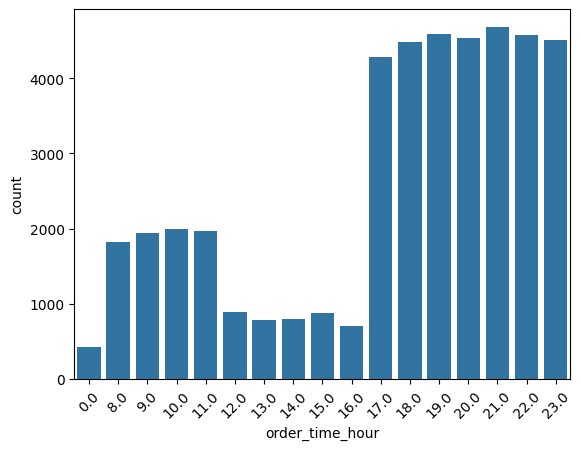

In [70]:
# categorical analysis on order_time_hour

categorical_analysis(df_final, "order_time_hour")

- 70% of total orders are delivered between 17 to 23 hour of the day
- mid night deliveries are least

,Count,Percentage
order_time_of_day,,
night,18312,40.24%
evening,13353,29.35%
morning,7718,16.96%
afternoon,4049,8.9%
after_midnight,2070,4.55%


**************************************************
The unique categories in order_time_of_day column are ['morning', 'evening', 'afternoon', 'night', 'after_midnight']
**************************************************
The number of categories in order_time_of_day column are 5


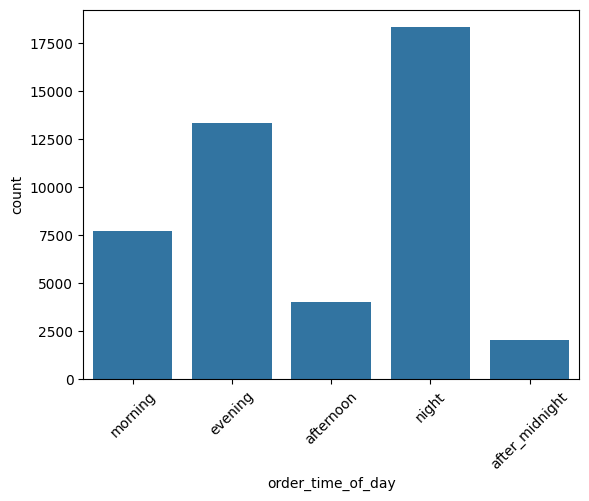

In [71]:
# categorical analysis on time of day

categorical_analysis(df_final, "order_time_of_day")

- night has highest orders while after_midnight has least orders

## Pickup Time

In [72]:
# pickup_time datatype

df_final['pickup_time_minutes'].dtype

dtype('float64')

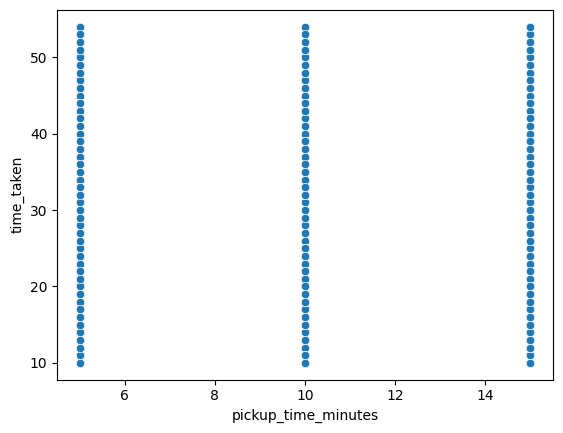

In [ ]:
# relationship between pickup time and delivery time

sns.scatterplot(df_final, x="pickup_time_minutes", y="time_taken")
plt.show()

- pickup_time_minutes column shows categorical nature thus we can  **Convert the column to ordinal categorical column**

,Count,Percentage
pickup_time_minutes,,
5.0,14703,33.52%
15.0,14610,33.31%
10.0,14549,33.17%


**************************************************
The unique categories in pickup_time_minutes column are [15.0, 5.0, 10.0, nan]
**************************************************
The number of categories in pickup_time_minutes column are 3


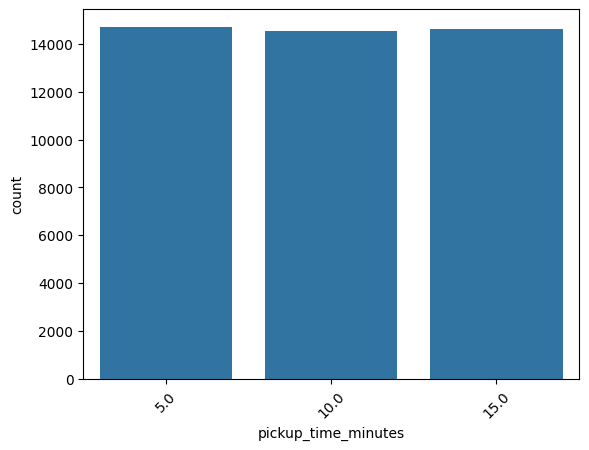

In [74]:
# pickup time categorical analysis

categorical_analysis(df_final, "pickup_time_minutes")

- uniform distribution of pickup_time_minutes column at 5, 10 and 15 minutes

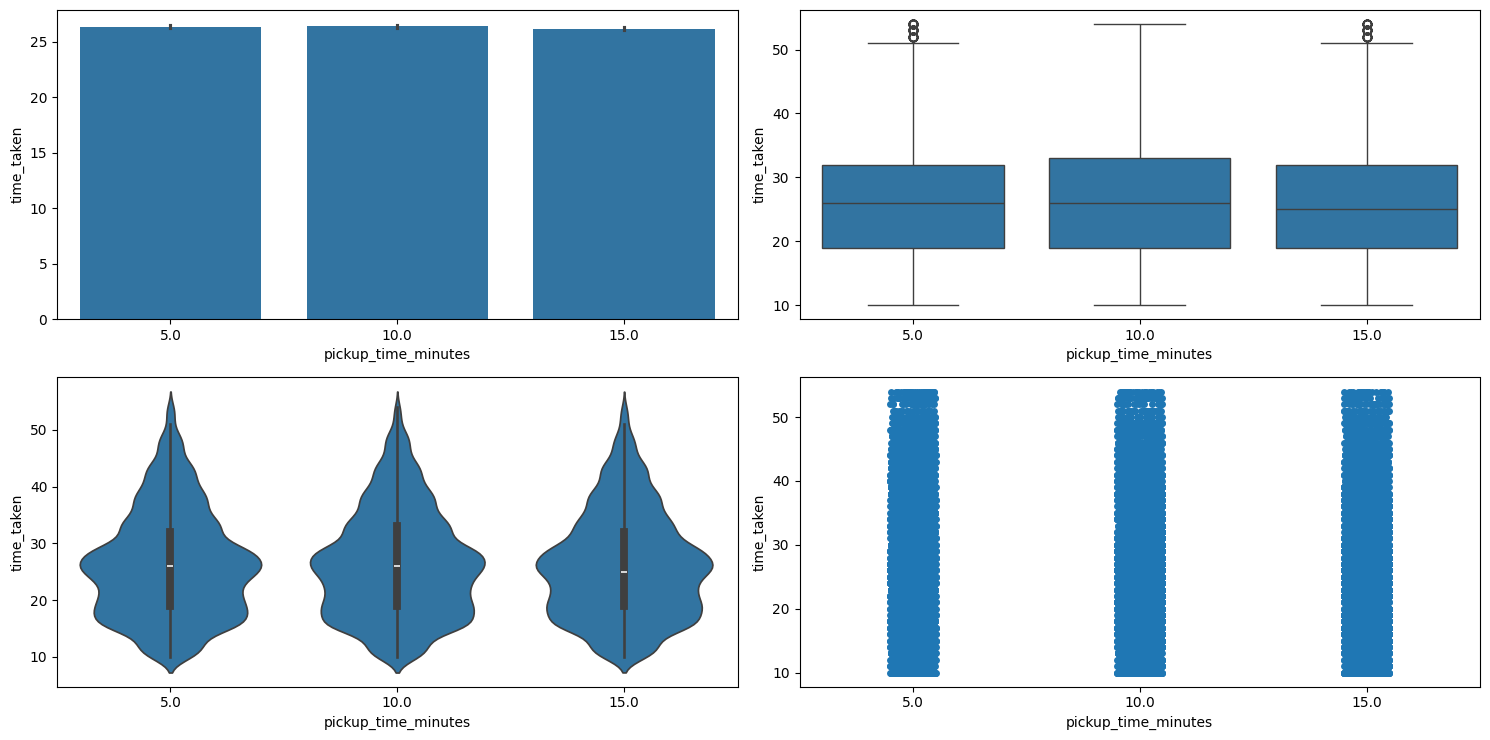

In [75]:
# does pickup time have an effect on delivery time

numerical_categorical_analysis(df_final, "pickup_time_minutes", "time_taken")

- pickup_time_minutes has slightly more time_taken at 10 minutes than 5 and 15 minutes

In [76]:
# hypothesis testing to prove point

anova_test(df_final, "time_taken", "pickup_time_minutes")

0.09932647028819426
Fail to reject the null hypothesis. There is no significant relationship between time_taken and pickup_time_minutes.


## Traffic

In [77]:
# datatype of traffic column

df_final['traffic'].dtype

<StringDtype(storage='python', na_value=nan)>

,Count,Percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


**************************************************
The unique categories in traffic column are ['high', 'jam', 'low', 'medium', nan]
**************************************************
The number of categories in traffic column are 4


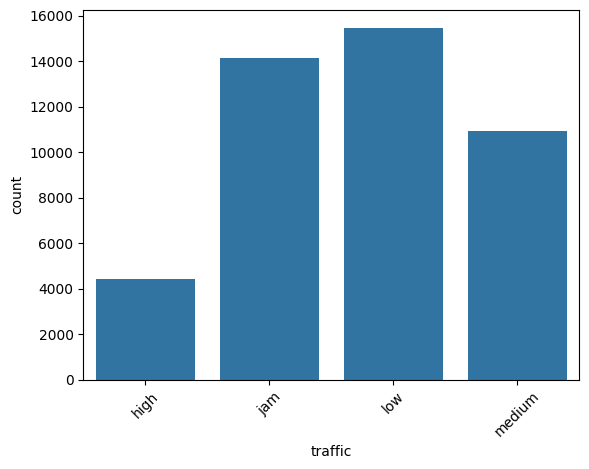

In [78]:
# categorical analysis on traffic

categorical_analysis(df_final, "traffic")

- high traffic is least while low traffic is most of time

In [79]:
# does traffic depends on type of city

chi_2_test(df_final, "traffic", "city_type")

2.3390790568495405e-104
Reject the null hypothesis. There is a significant association between traffic and city_type.


In [80]:
# does traffic depends on city

chi_2_test(df_final, "traffic", "city_name")

0.4978080180955253
Fail to reject the null hypothesis. There is no significant association between traffic and city_name.


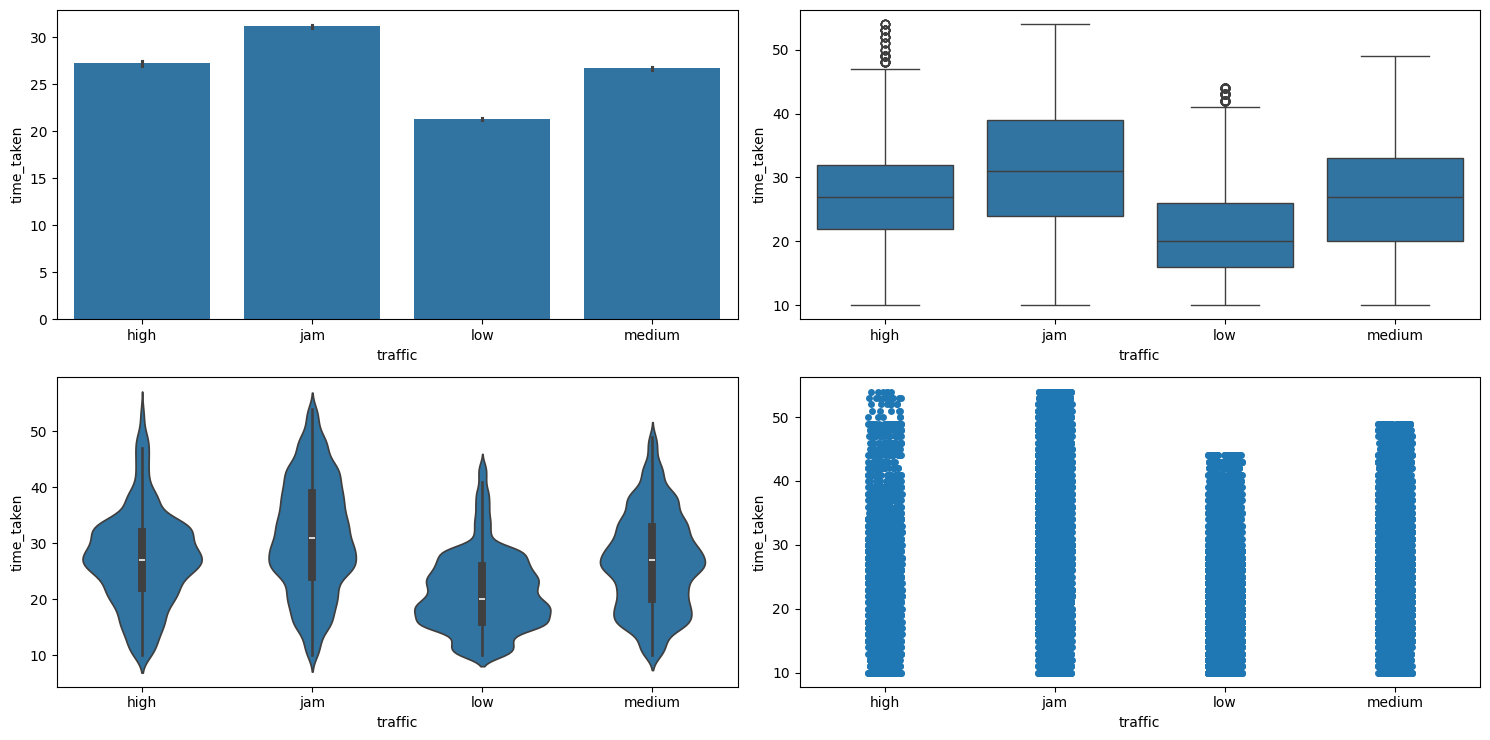

In [81]:
# does traffic affects delivery times

numerical_categorical_analysis(df_final, "traffic", "time_taken")

- jam takes more time_taken and low traffic takes least time_taken to deliver the food

In [82]:
# hypothesis test on does traffic affects delivery times

anova_test(df_final, "time_taken", "traffic")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and traffic.


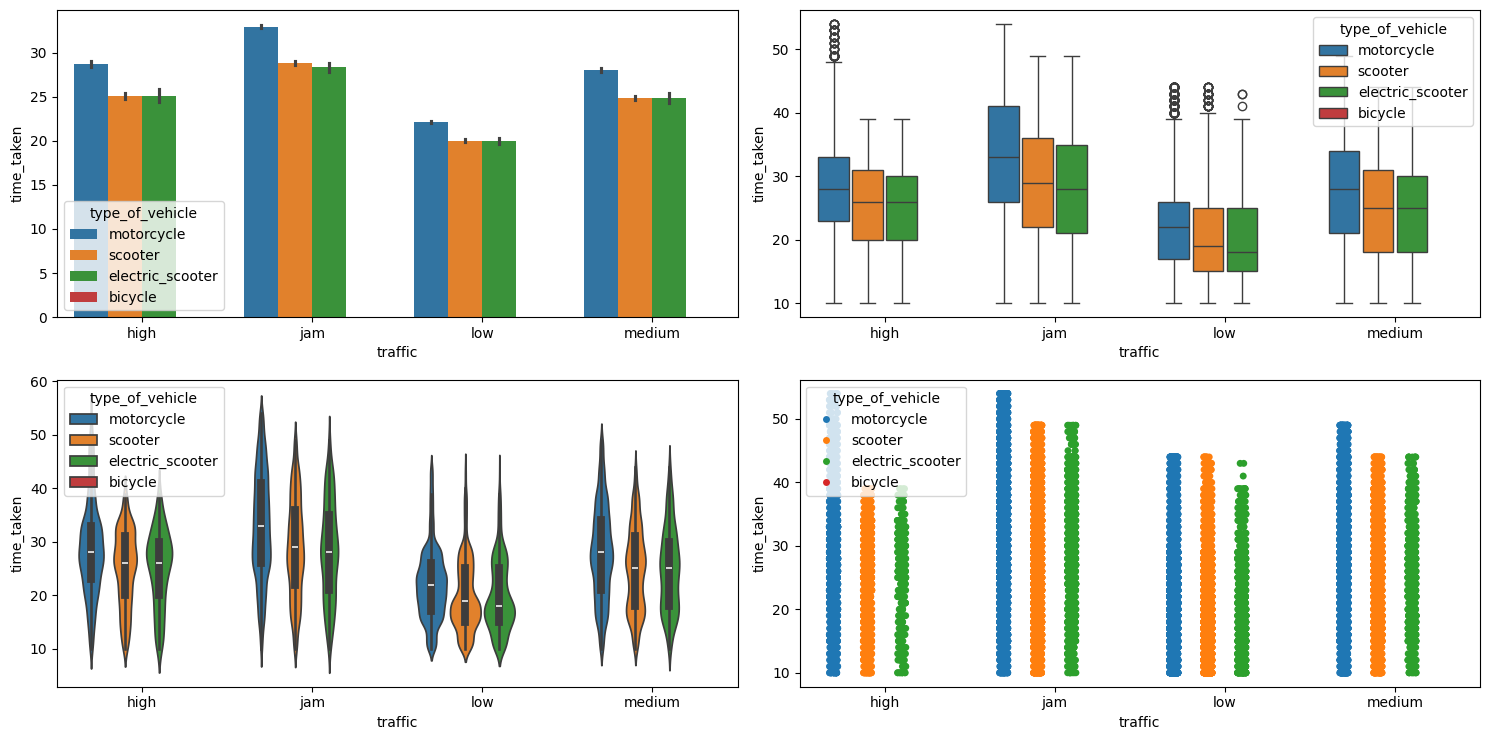

In [83]:
# are some vehicle types more suitable in traffic than others

multivariate_analysis(df_final, "time_taken", "traffic", "type_of_vehicle")

- motorcycle takes highest time_taken while scooter and electric_scooter takes least time_taken to deliver the food

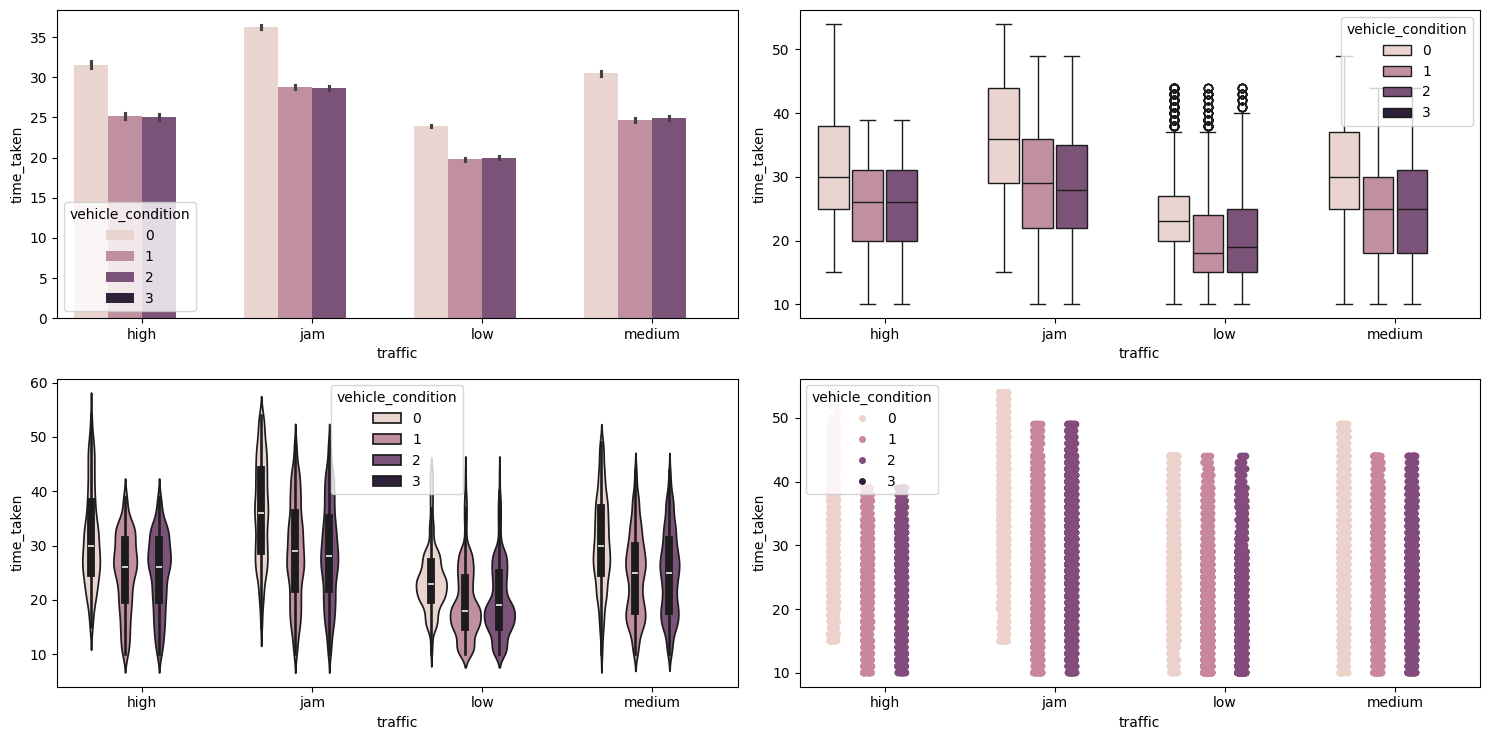

In [133]:
# does vehicle condition in traffic situations affects delivery times

multivariate_analysis(df_final, "time_taken", "traffic", "vehicle_condition")

- good condition of vehicles got longer deliveries specially in high and jam traffic condition. **Dont make wrong interpretations that good condition vehicles takes longer times on avg**. This simply means that good vehicles are preferred for deliveries during festivals which results in longer delivery times
- 1 and 2 condition of bechicles got same type of deliveries in all traffic conditions

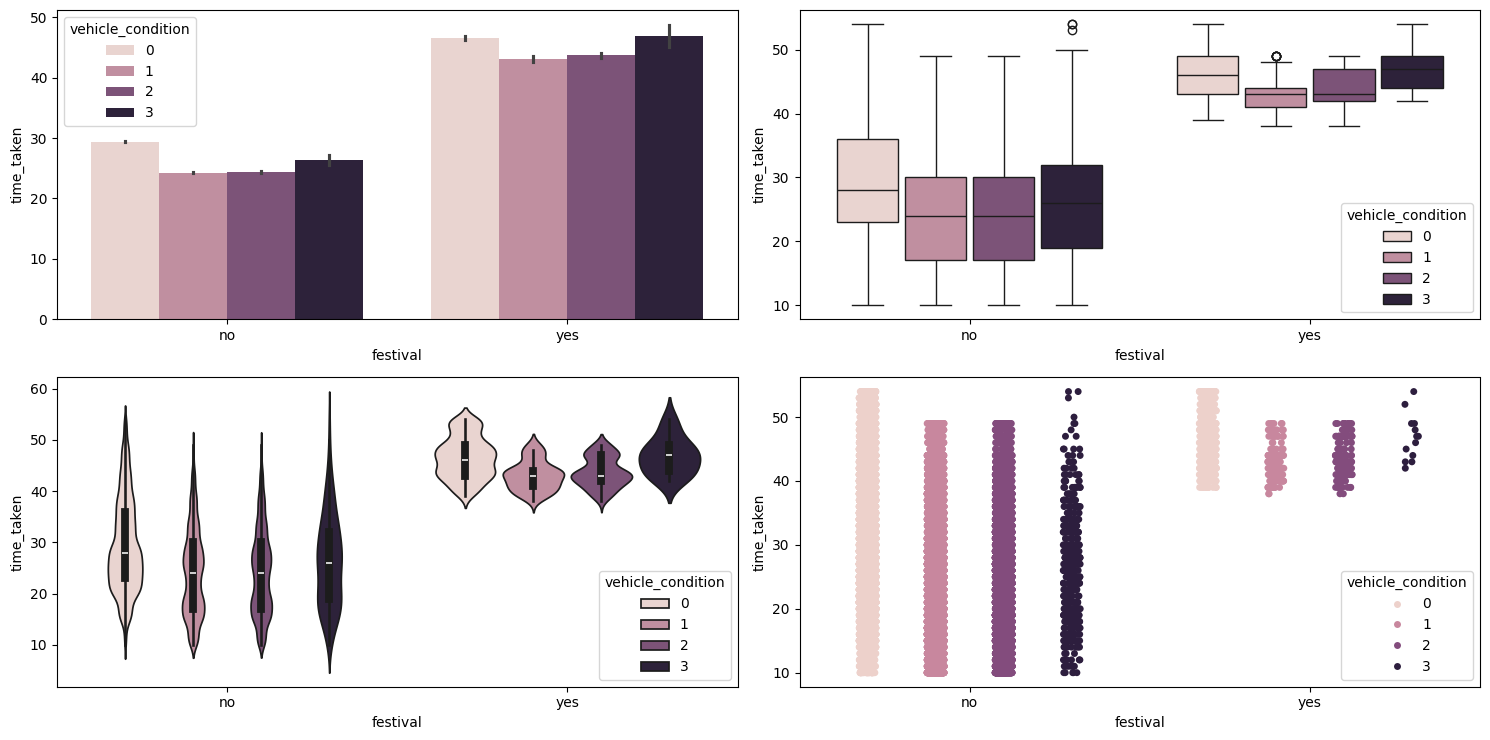

In [85]:
multivariate_analysis(df_final, "time_taken", "festival", "vehicle_condition")

- 3 vehicle condition got very less deliveries in festival season
- 3 takes more time thena 2 and 2 takes more time than 1 and 1 takes least time to deliver the food
NOTE: 0 takes maximum time because it got longest deliveries

## Multiple Deliveries

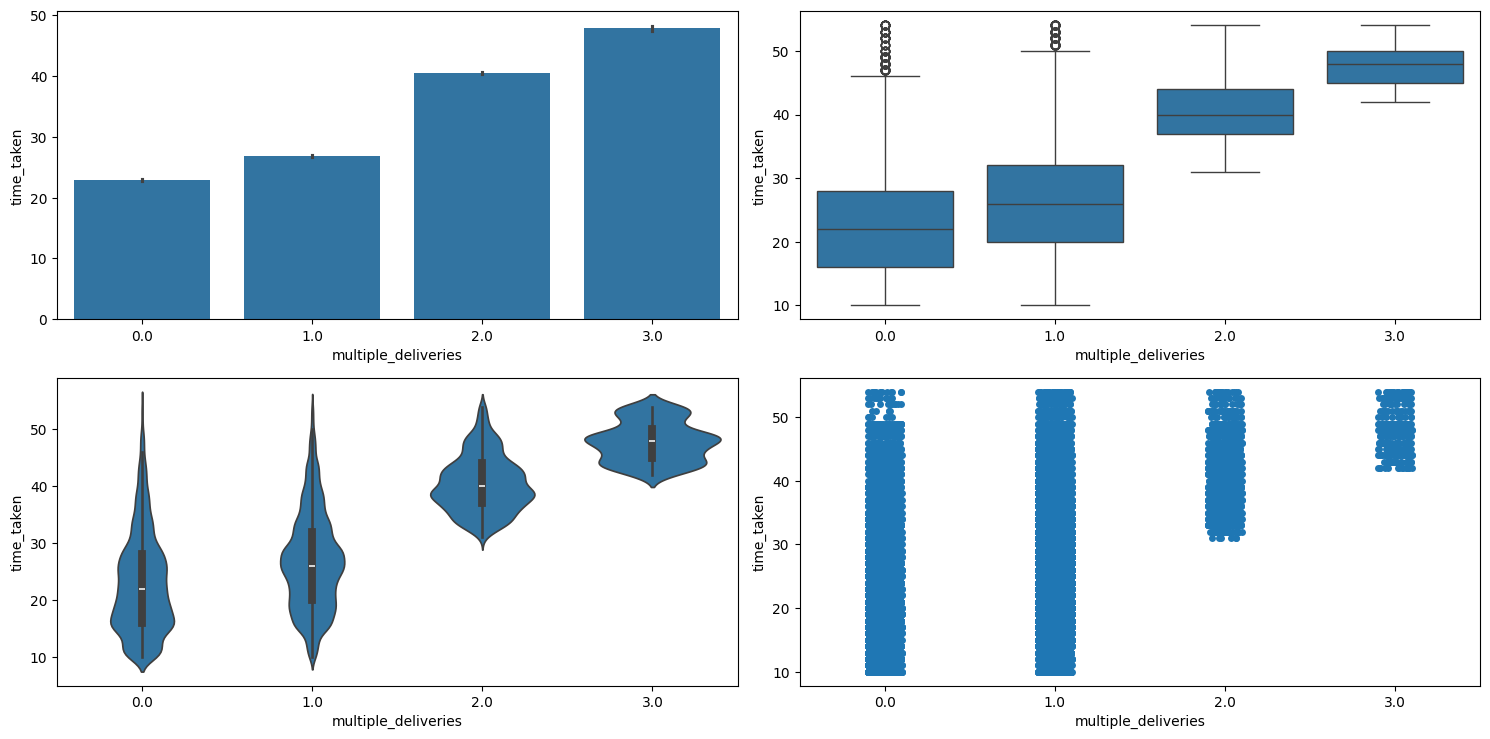

In [86]:
# does multiple delivereis affect delivery times

numerical_categorical_analysis(df_final, "multiple_deliveries", "time_taken")

- on increase the deliveries, average time_taken increases
- multiple deliveries takes longer time to deliver the food than single delivery

In [87]:
# hypothesis test

anova_test(df_final, "time_taken", "multiple_deliveries")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and multiple_deliveries.


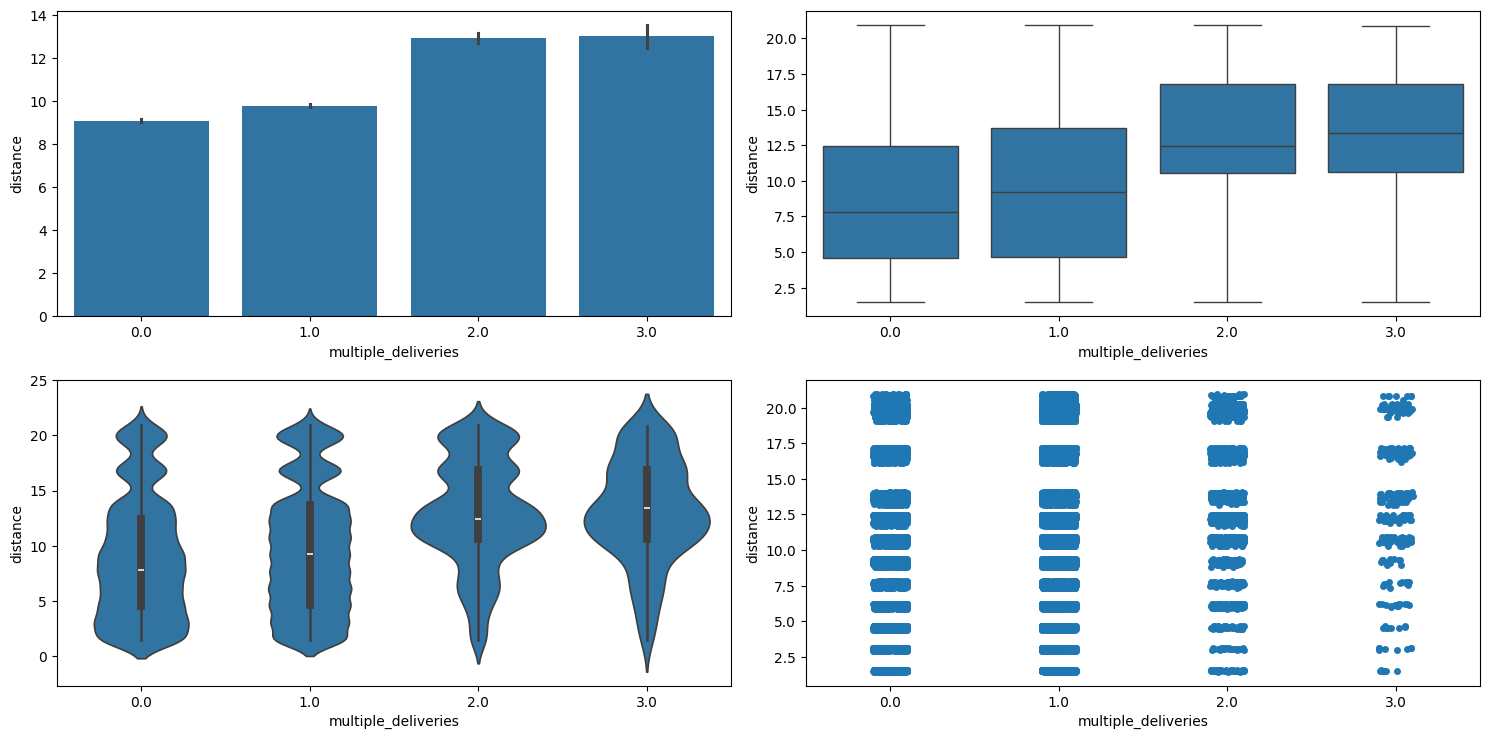

In [88]:
# do multiple deliveries are of longer distances

numerical_categorical_analysis(df_final, "multiple_deliveries", "distance")

- multiple deliveries have to travel more distance

## Weather

In [89]:
# data type of weather column

df_final['weather'].dtype

<StringDtype(storage='python', na_value=nan)>

,Count,Percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


**************************************************
The unique categories in weather column are ['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
**************************************************
The number of categories in weather column are 6


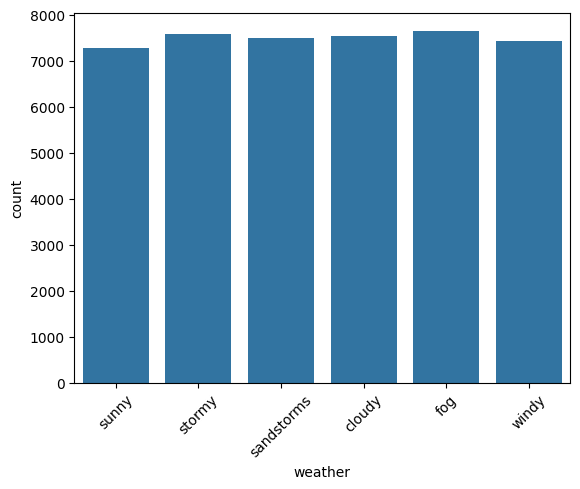

In [90]:
# categorical analysis on type of weather

categorical_analysis(df_final, "weather")

- weather condition are uniformly distributed

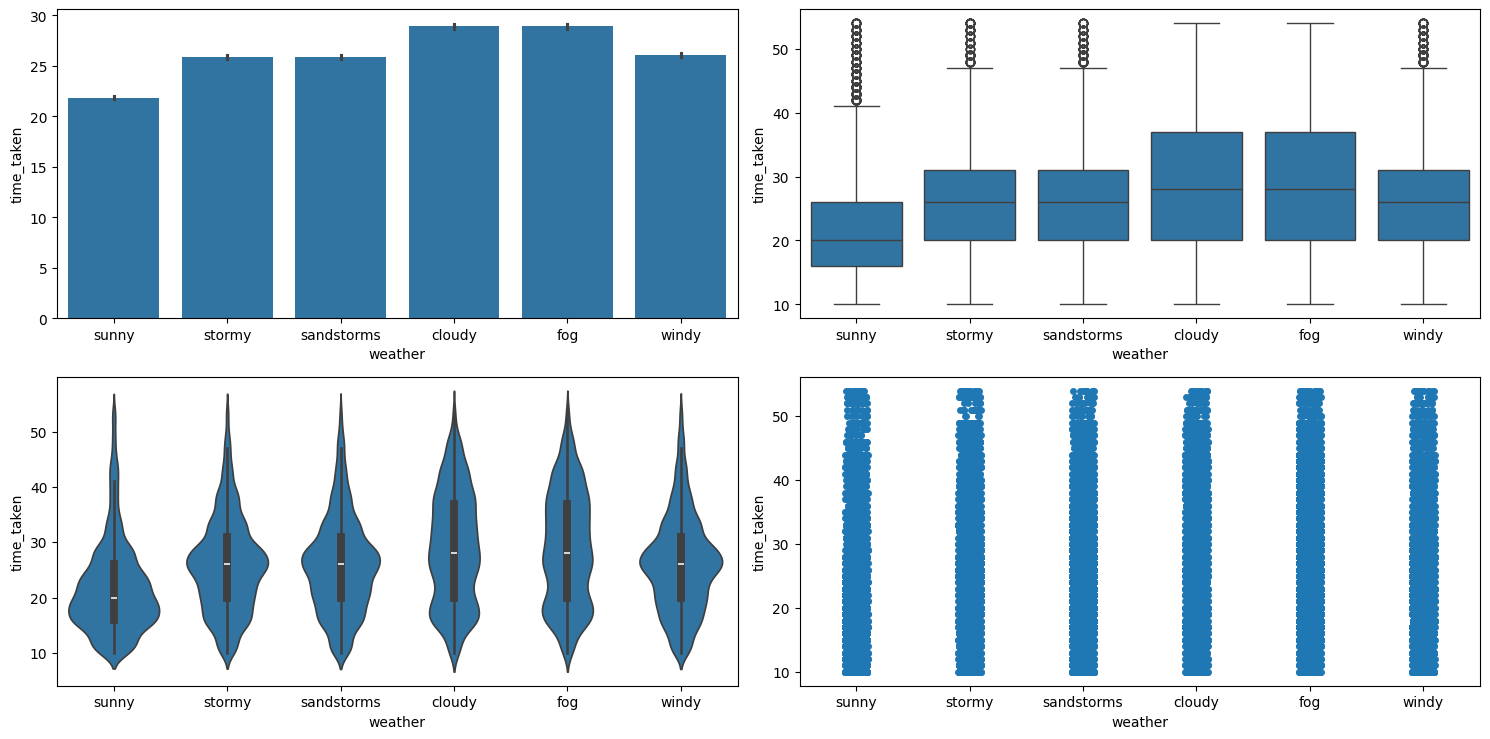

In [91]:
# does weather affect delivery times

numerical_categorical_analysis(df_final, "weather", "time_taken")

- sunny weather condition takes least time_taken while cloudy and fog weather condition takes more time_taken to deliver the food

In [92]:
# hypothesis test

anova_test(df_final, "time_taken", "weather")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and weather.


In [93]:
# does the weather affects traffic

chi_2_test(df_final, "weather", "traffic")

0.4796388074753828
Fail to reject the null hypothesis. There is no significant association between weather and traffic.


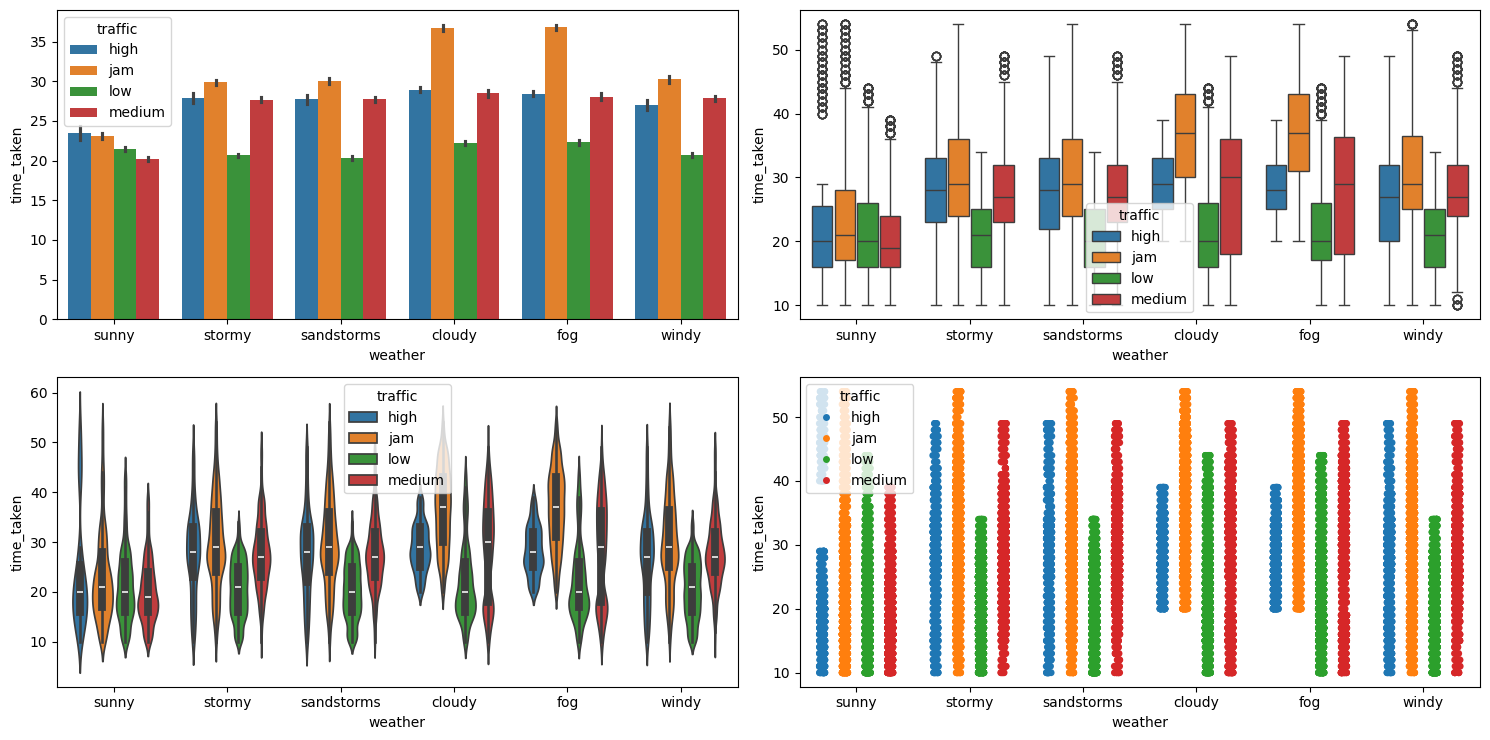

In [94]:
# delivery times based on weather and traffic

multivariate_analysis(df_final, "time_taken", "weather", "traffic")

- other than sunny weather condition, all other weather conditions takes same time_taken to deliver the food on a given traffic condition. But, on sunny weather condition, high and jam takes most time_taken to deliver the food while low and medium takes least time_taken to deliver the food
- **Seems like traffic along with other features combined acts as great discriminatory feature**

In [95]:
# pivot table

df_final.pivot_table(index="weather",columns="traffic",values="time_taken",aggfunc="mean")

traffic,high,jam,low,medium
weather,,,,
cloudy,28.940860,36.689655,22.208445,28.483134
fog,28.426546,36.806916,22.303427,28.044816
sandstorms,27.711840,30.018758,20.297049,27.738522
stormy,27.845839,29.850194,20.681734,27.680502
sunny,23.448980,23.082132,21.449293,20.195518
windy,26.972789,30.219056,20.665862,27.888769


- traffic is more effect the time_taken to deliver the food than weather condition

## Vehicle - Condition and Type

,Count,Percentage
vehicle_condition,,
2,15034,33.04%
1,15030,33.03%
0,15009,32.99%
3,429,0.94%


**************************************************
The unique categories in vehicle_condition column are [2, 0, 1, 3]
**************************************************
The number of categories in vehicle_condition column are 4


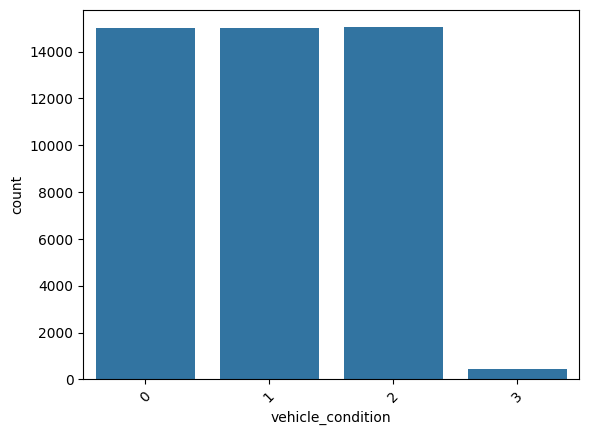

In [96]:
# categorical analysis on vehicle condition

categorical_analysis(df_final, "vehicle_condition")

- other than 3 vihicle condition, all other vehicle conditions have same number of deliveries. 3 vehicle condition have least number of deliveries

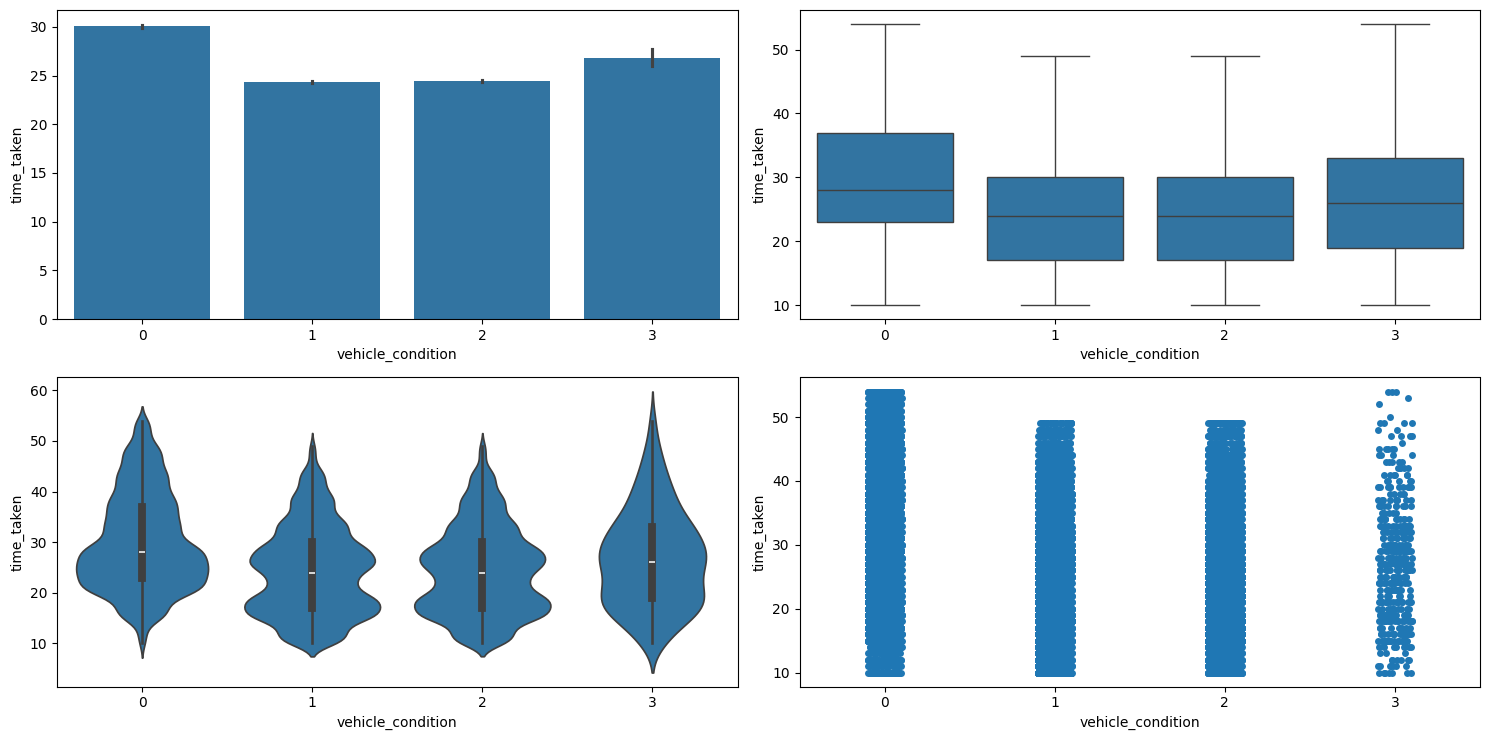

In [97]:
# does vehicle condition affect delivery times

numerical_categorical_analysis(df_final, "vehicle_condition", "time_taken")

In [98]:
# anova test

anova_test(df_final, "time_taken", "vehicle_condition")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and vehicle_condition.


,Count,Percentage
type_of_vehicle,,
motorcycle,26427,58.08%
scooter,15244,33.5%
electric_scooter,3778,8.3%
bicycle,53,0.12%


**************************************************
The unique categories in type_of_vehicle column are ['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
**************************************************
The number of categories in type_of_vehicle column are 4


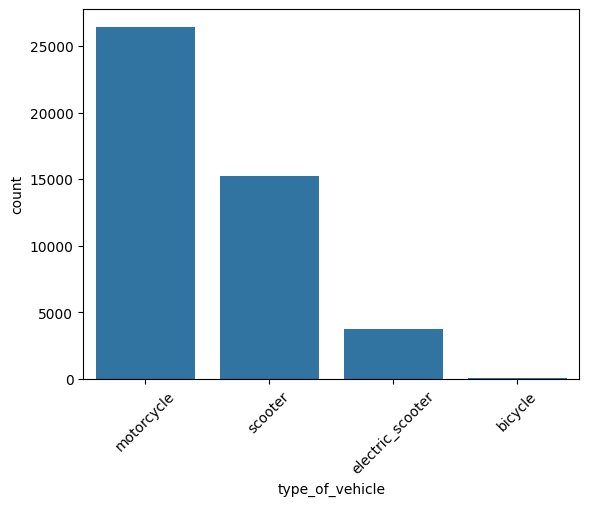

In [99]:
# analysis on vehicle type

categorical_analysis(df_final, "type_of_vehicle")

- motorcycle has highest deliveries while bicycle has least deliveries

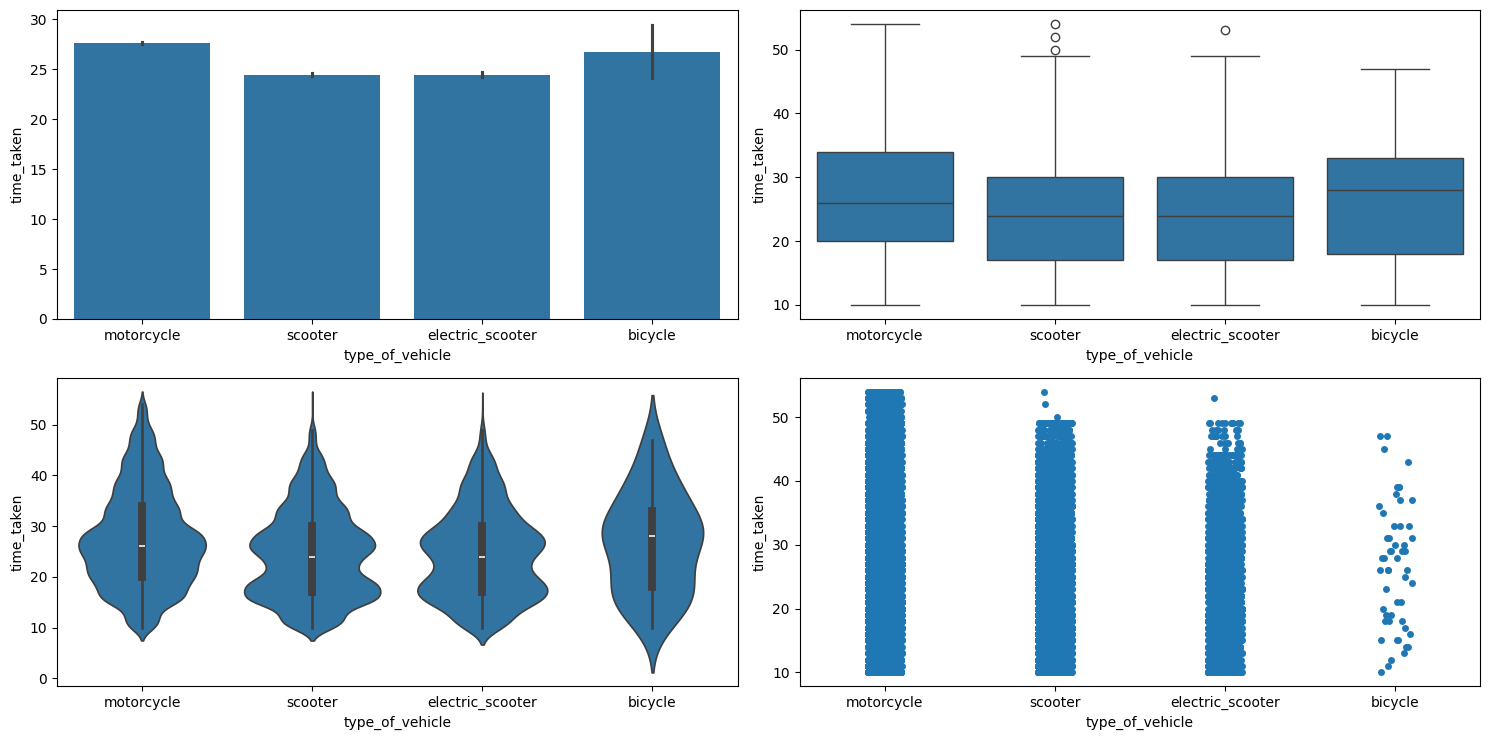

In [100]:
# does the type of vehicle affects delivery time

numerical_categorical_analysis(df_final, "type_of_vehicle", "time_taken")

- motorcycle takes highest time_taken because they got longer distance deliveries

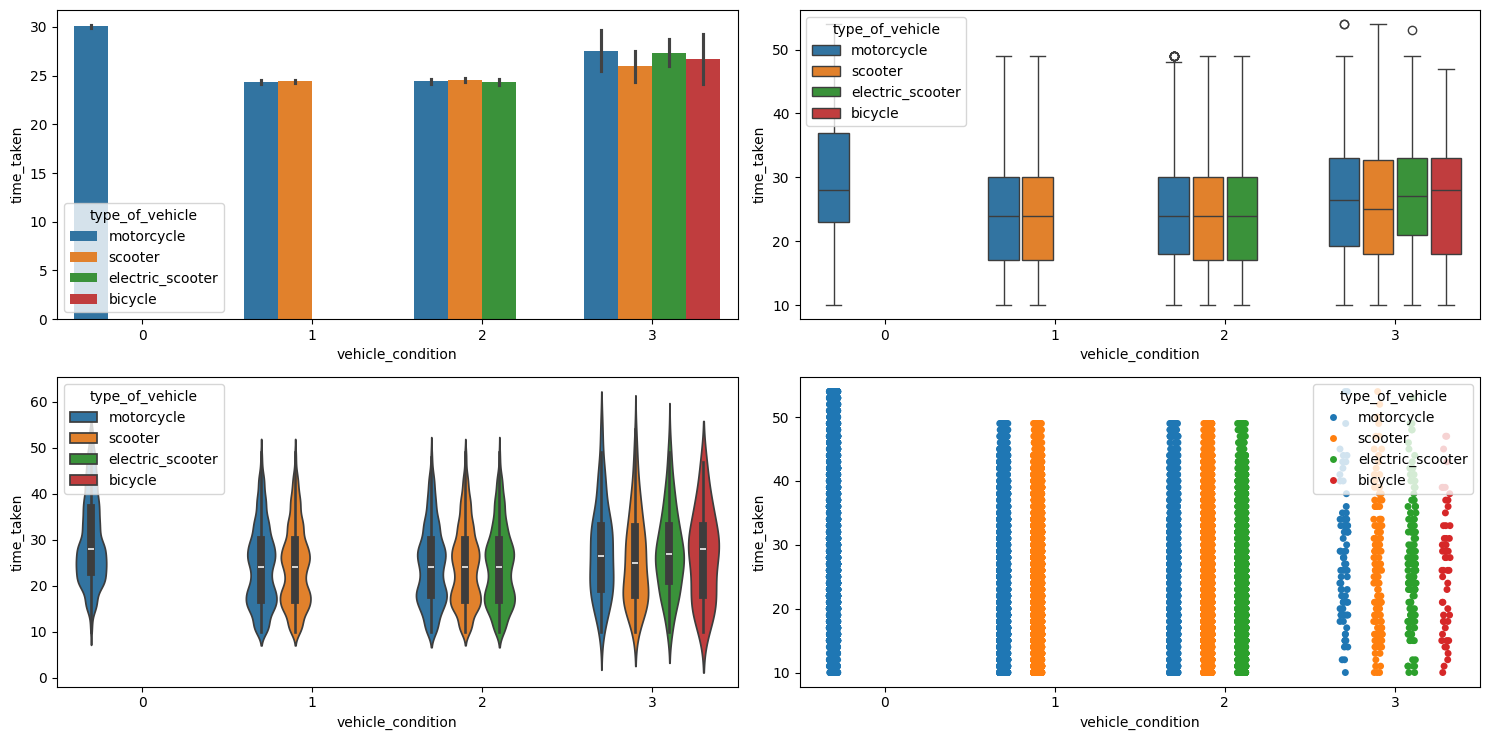

In [101]:
# vehicle condition and type

multivariate_analysis(df_final, "time_taken", "vehicle_condition", "type_of_vehicle")

- 0 vehicle condition only have motorcycles and have highest average time_taken to deliver the food
- 1 vehicle condition have motorcycle and scooters
- 2 vehicle condition have motorcycle, scooters and electric_scooter
- 3 vehicle condition have motorcycle, scooters, electric_scooter and bicycle and got least deliveries

In [102]:
# is their a relation between vehicle type and conditions

chi_2_test(df_final, "type_of_vehicle", "vehicle_condition")

0.0
Reject the null hypothesis. There is a significant association between type_of_vehicle and vehicle_condition.


## Type of Order

In [103]:
# type of order dtype

df_final['type_of_order'].dtype

<StringDtype(storage='python', na_value=nan)>

,Count,Percentage
type_of_order,,
snack,11512,25.3%
meal,11435,25.13%
drinks,11294,24.82%
buffet,11261,24.75%


**************************************************
The unique categories in type_of_order column are ['snack', 'drinks', 'buffet', 'meal']
**************************************************
The number of categories in type_of_order column are 4


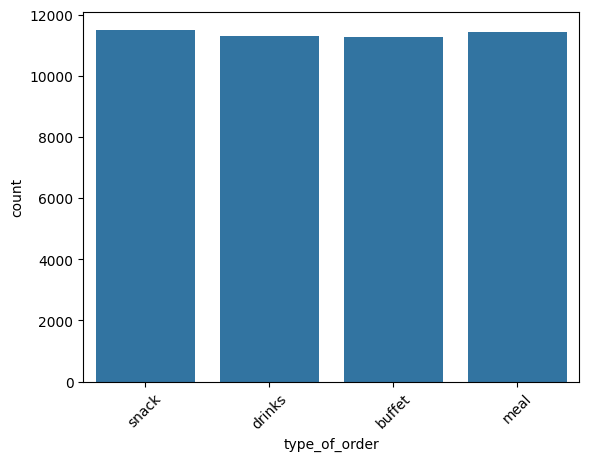

In [104]:
# analysis on type of order

categorical_analysis(df_final, "type_of_order")

- type_of_order are uniformly distributed

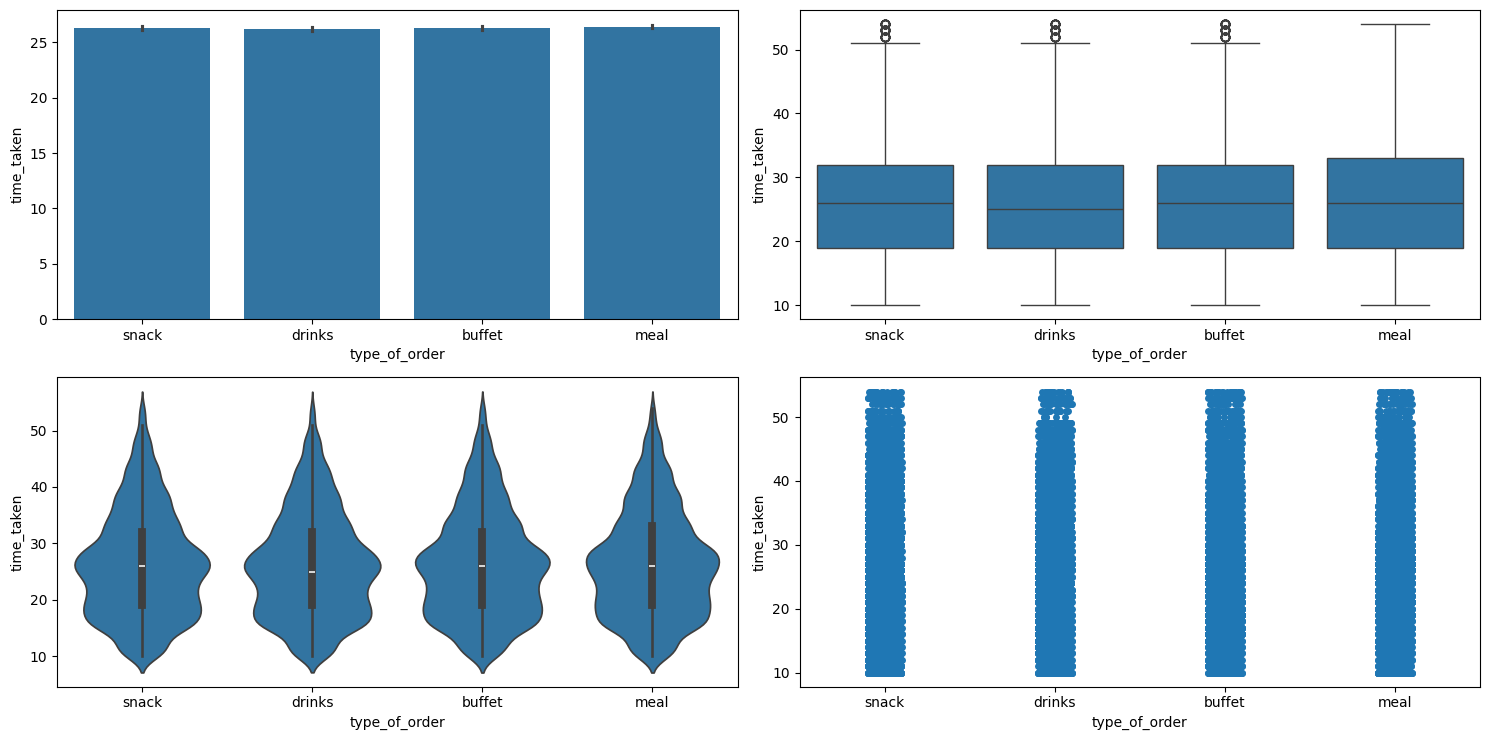

In [105]:
# does order type have have effect on delivery times

numerical_categorical_analysis(df_final, "type_of_order", "time_taken")

In [106]:
# hypothesis test

anova_test(df_final, "time_taken", "type_of_order")

0.3043309877314636
Fail to reject the null hypothesis. There is no significant relationship between time_taken and type_of_order.


- We can drop the type_of_order column as it don't effect the time_taken and no relationship between type_of_order and time_taken to deliver the food

In [ ]:
# contingency table

pd.crosstab(df_final["type_of_order"], df_final["is_weekend"])

is_weekend,0,1
type_of_order,,
buffet,8238,3023
drinks,8130,3164
meal,8290,3145
snack,8337,3175


In [ ]:
# does type of order have an effect over pickup time

chi_2_test(df_final, "pickup_time_minutes", "type_of_order")

0.49118080317709845
Fail to reject the null hypothesis. There is no significant association between pickup_time_minutes and type_of_order.


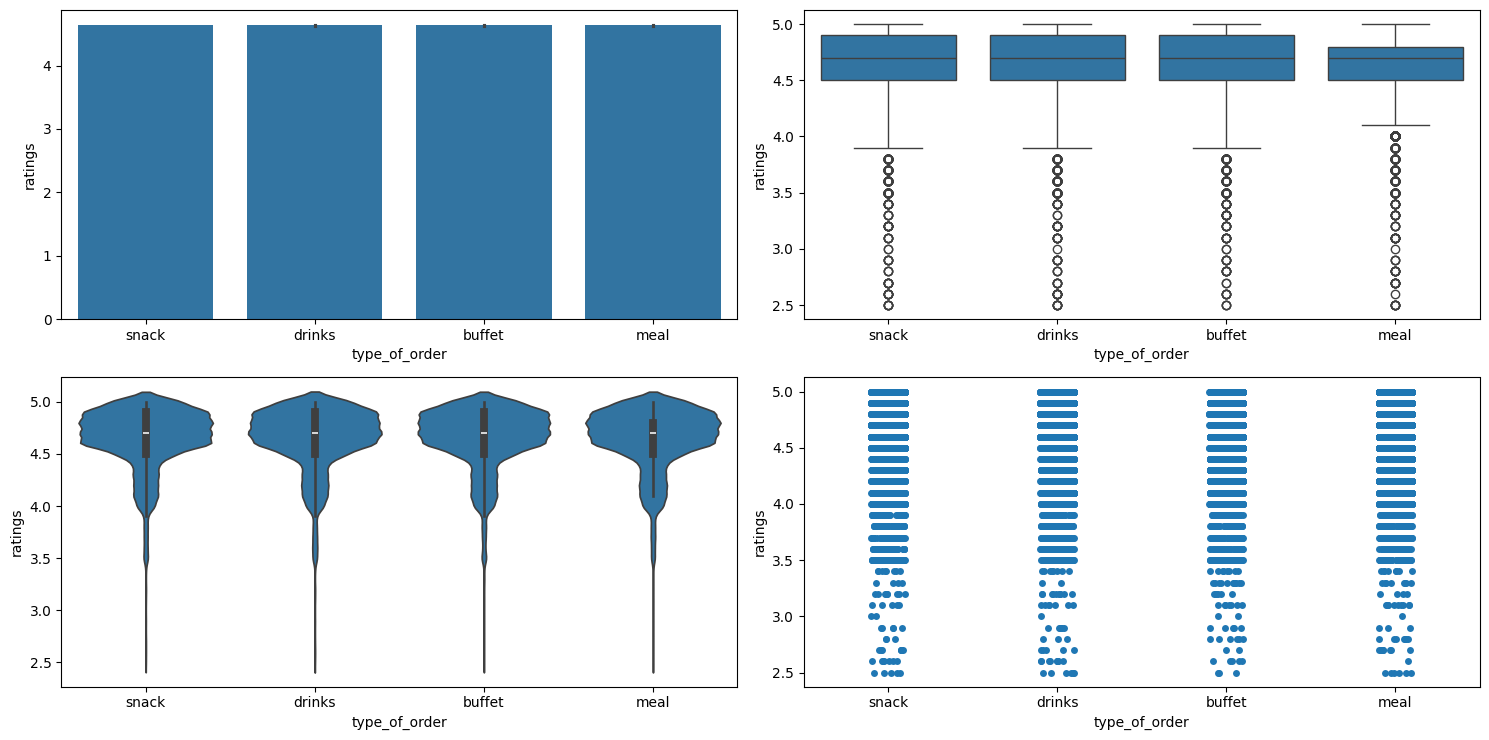

In [109]:
# does order type has an effect on ratings

numerical_categorical_analysis(df_final, "type_of_order", "ratings")

In [110]:
# is their a relationship between weekends and type of order

chi_2_test(df_final, "is_weekend", "type_of_order")

0.2658161540207276
Fail to reject the null hypothesis. There is no significant association between is_weekend and type_of_order.


In [111]:
# is their a relationship between festivals and type of order

chi_2_test(df_final, "festival", "type_of_order")

0.6149018072722126
Fail to reject the null hypothesis. There is no significant association between festival and type_of_order.


## City Name

,Count,Percentage
city_name,,
JAP,3439,7.56%
RANCHI,3222,7.08%
BANG,3184,7.0%
SUR,3182,6.99%
HYD,3177,6.98%
MUM,3168,6.96%
MYS,3164,6.95%
COIMB,3162,6.95%
VAD,3159,6.94%


**************************************************
The unique categories in city_name column are ['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH', 'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA', 'AURG', 'AGR', 'VAD', 'ALH', 'BHP']
**************************************************
The number of categories in city_name column are 22


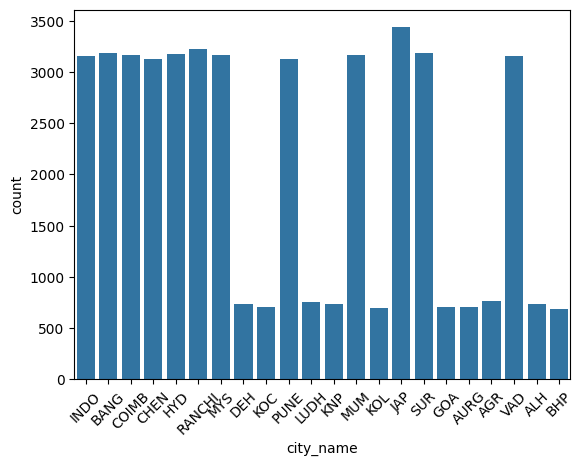

In [112]:
# categorical analysis on city name

categorical_analysis(df_final, "city_name")

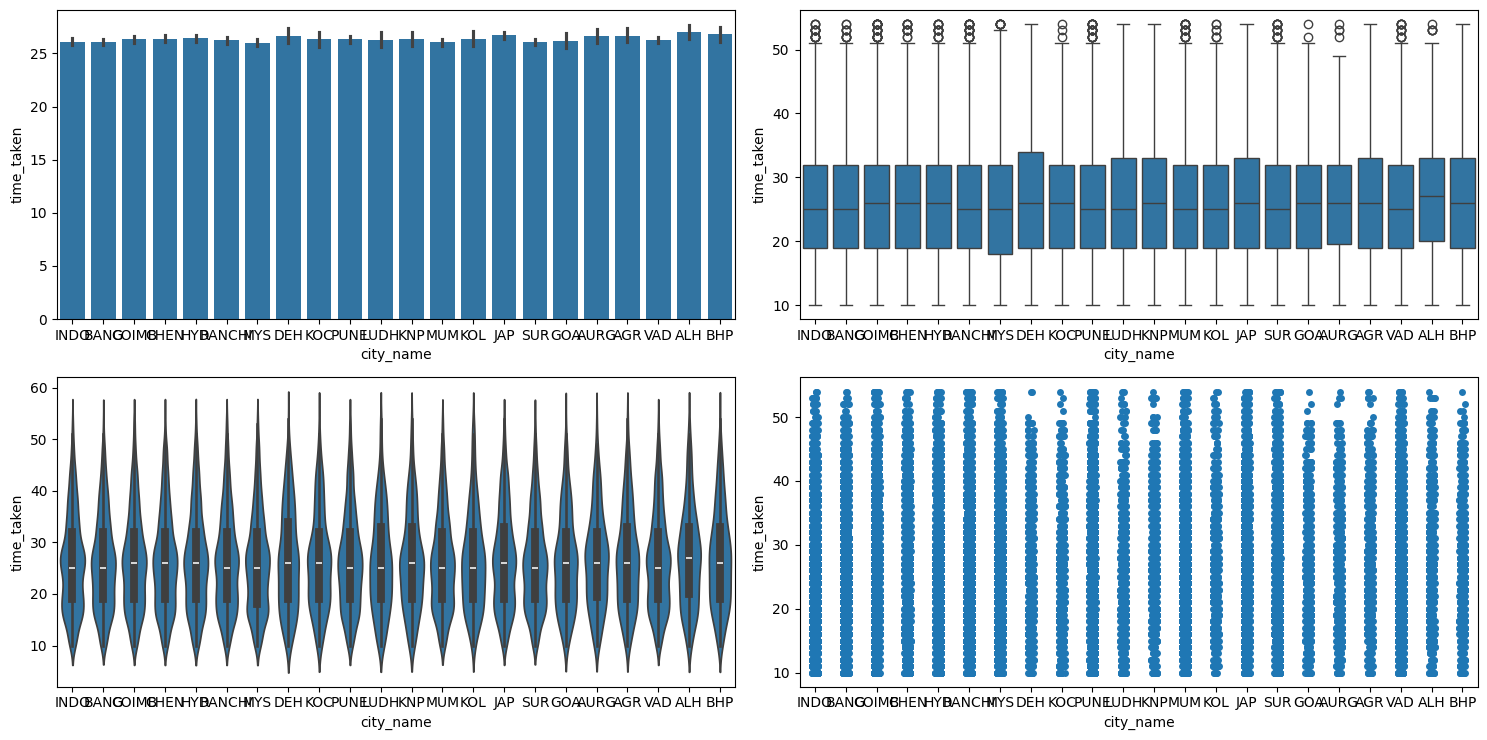

In [113]:
# does a city affects delivery times

numerical_categorical_analysis(df_final, "city_name", "time_taken")

,Count,Percentage
city_type,,
metropolitian,34029,76.81%
urban,10111,22.82%
semi-urban,164,0.37%


**************************************************
The unique categories in city_type column are ['urban', 'metropolitian', 'semi-urban', nan]
**************************************************
The number of categories in city_type column are 3


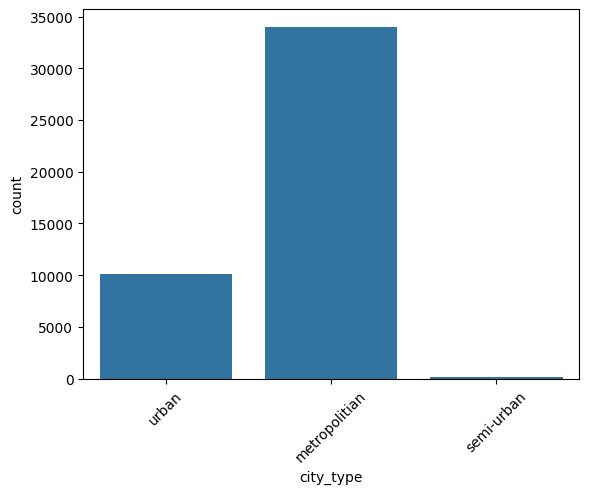

In [114]:
# categorical analysis on city type

categorical_analysis(df_final, "city_type")

- semi-urban has least orders

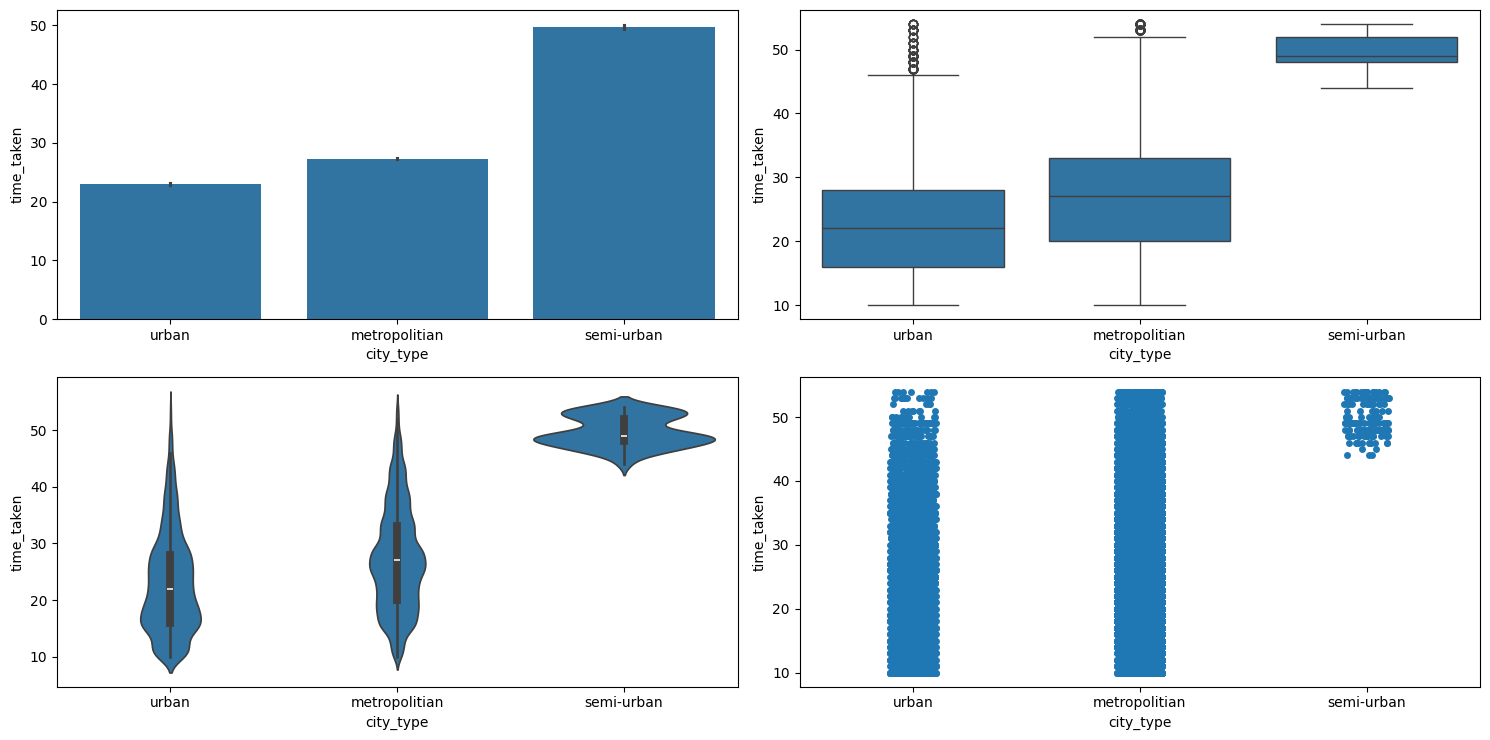

In [115]:
# does city types affect delivery times

numerical_categorical_analysis(df_final, "city_type", "time_taken")

- semi-urban has highest time_taken due to far away restaurants and less infrastructure than urban and metropolitian cities
- metropolitian has slightly higher time_taken than urban

In [116]:
# hypothesis test

anova_test(df_final, "time_taken", "city_type")

0.0
Reject the null hypothesis. There is a significant relationship between time_taken and city_type.


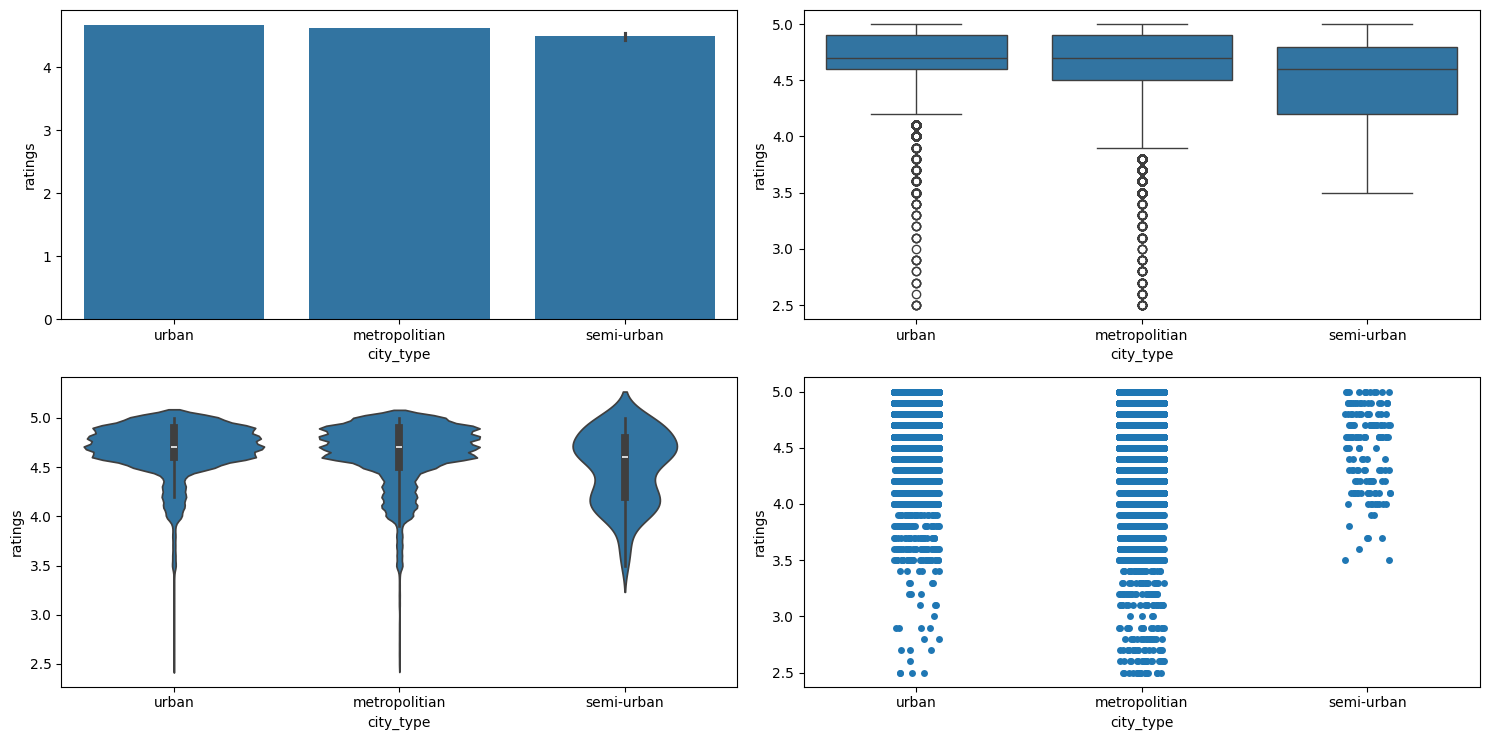

In [117]:
# does city type affects rider ratings

numerical_categorical_analysis(df_final, "city_type", "ratings")

- semi-urban got slightly less ratings than urban and metropolitian, but semi-urban don't got low ratings below 3.5

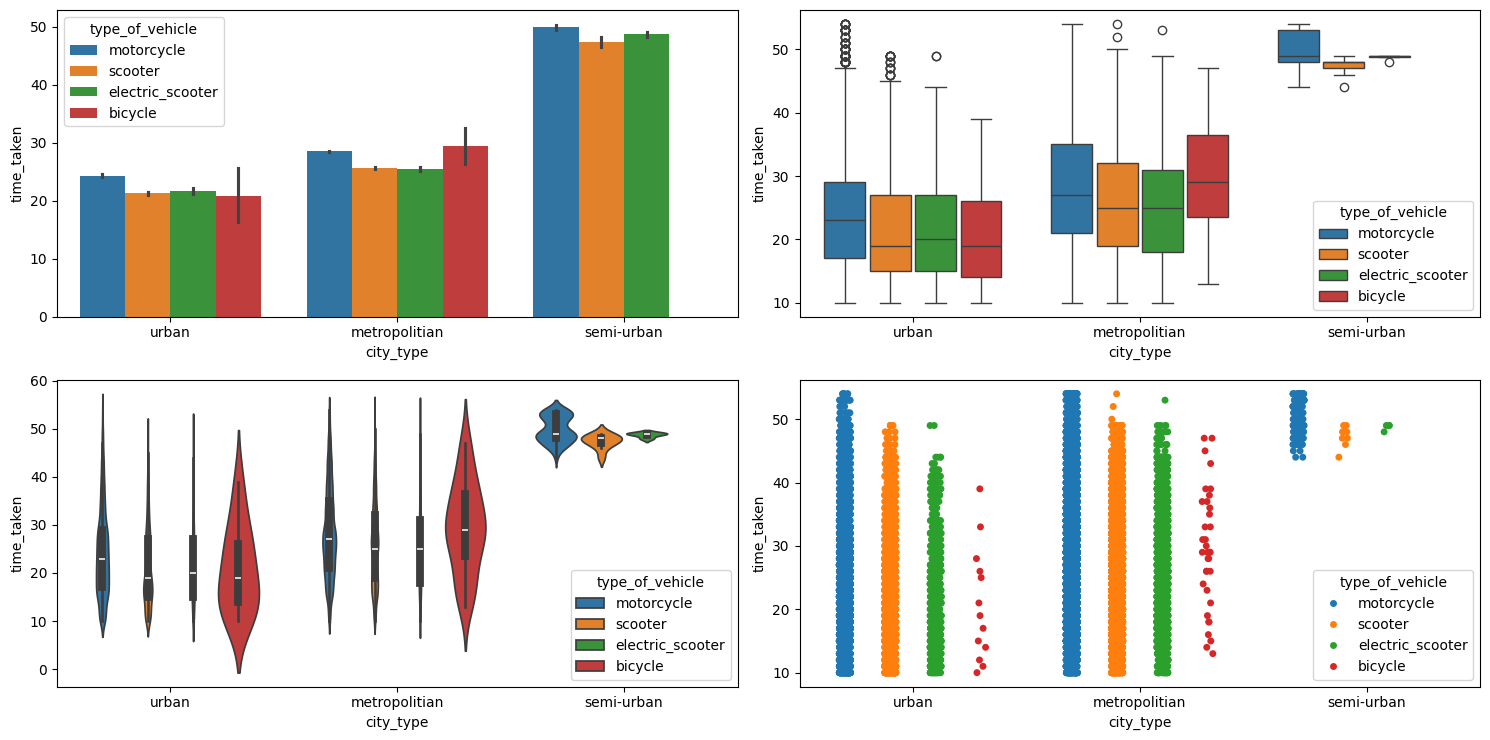

In [118]:
# city type, type of vehicle and delivery time analysis

multivariate_analysis(df_final, "time_taken", "city_type", "type_of_vehicle")

- - semi-urban have no use of bicycle

## Distance

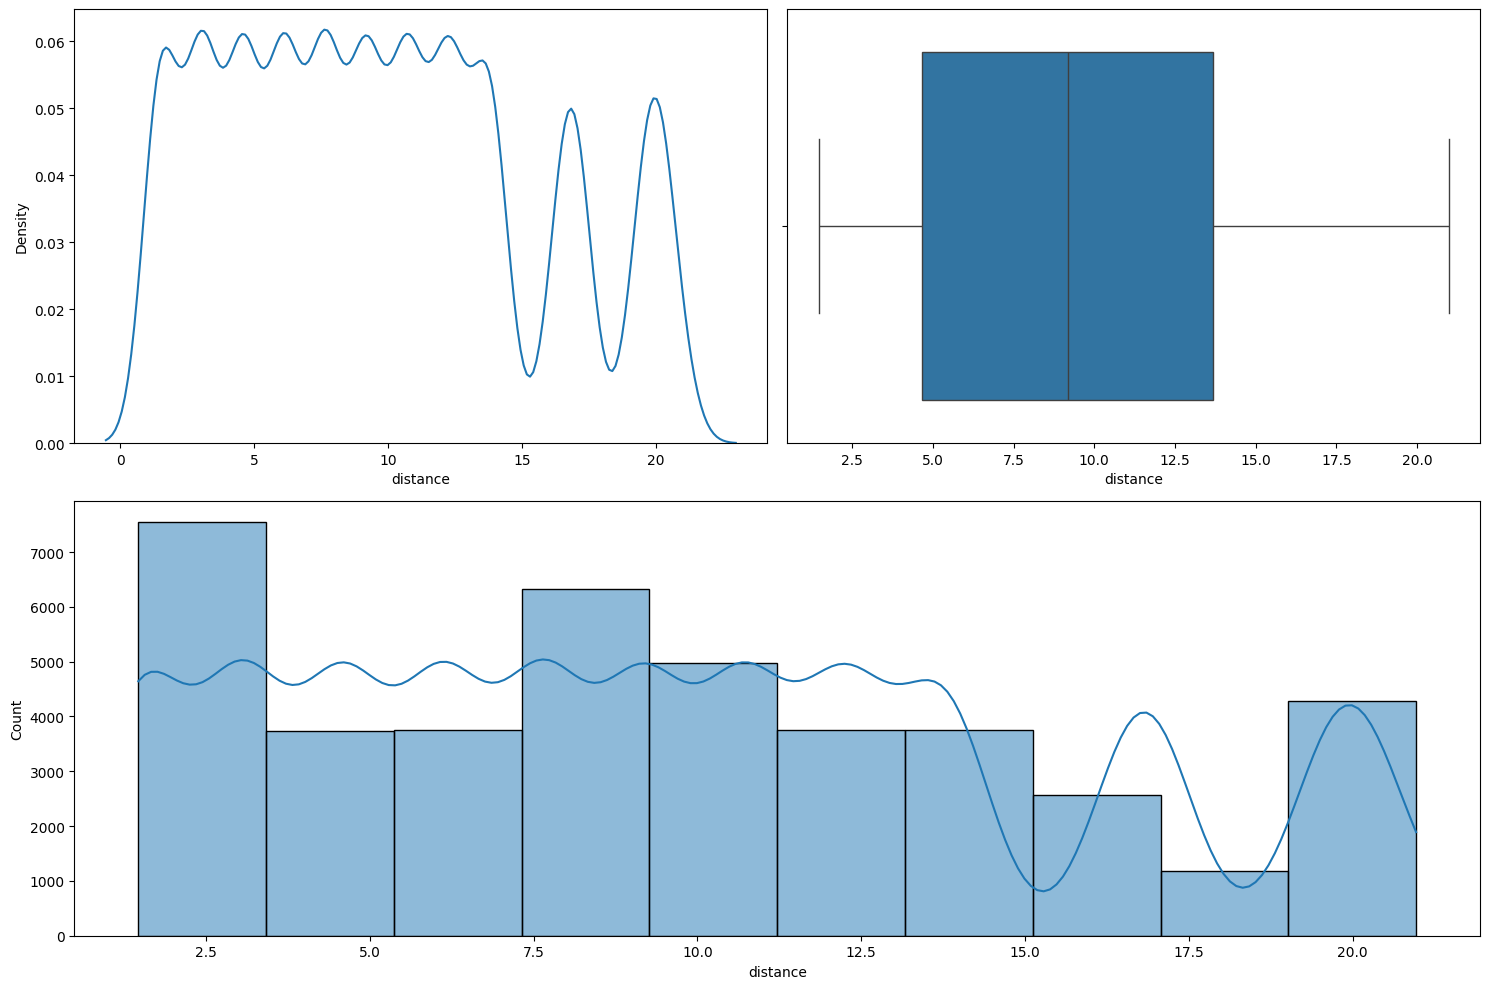

In [119]:
# numerical analysis of distance

numerical_analysis(df_final, "distance",bins=10)

- multiple peaks in distance column means it is discontinuous in nature

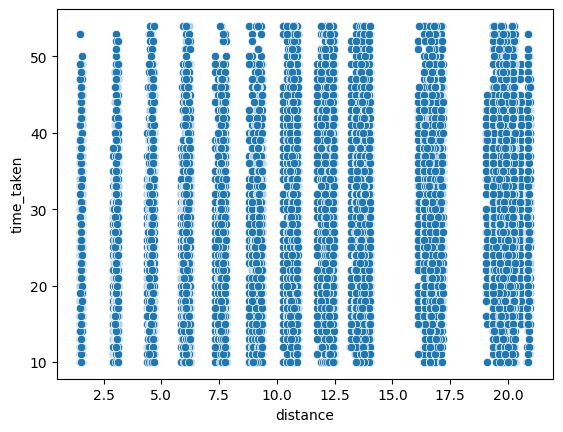

In [120]:
# relationship between distance and delivery times

sns.scatterplot(df_final,x="distance",y="time_taken")
plt.show()

- high distance have more thickness means there are more deliveries with high distance

In [121]:
# corr

df_final[["distance","time_taken"]].corr()

,distance,time_taken
distance,1.000000,0.320705
time_taken,0.320705,1.000000


- there is week correlation between distance and time_taken

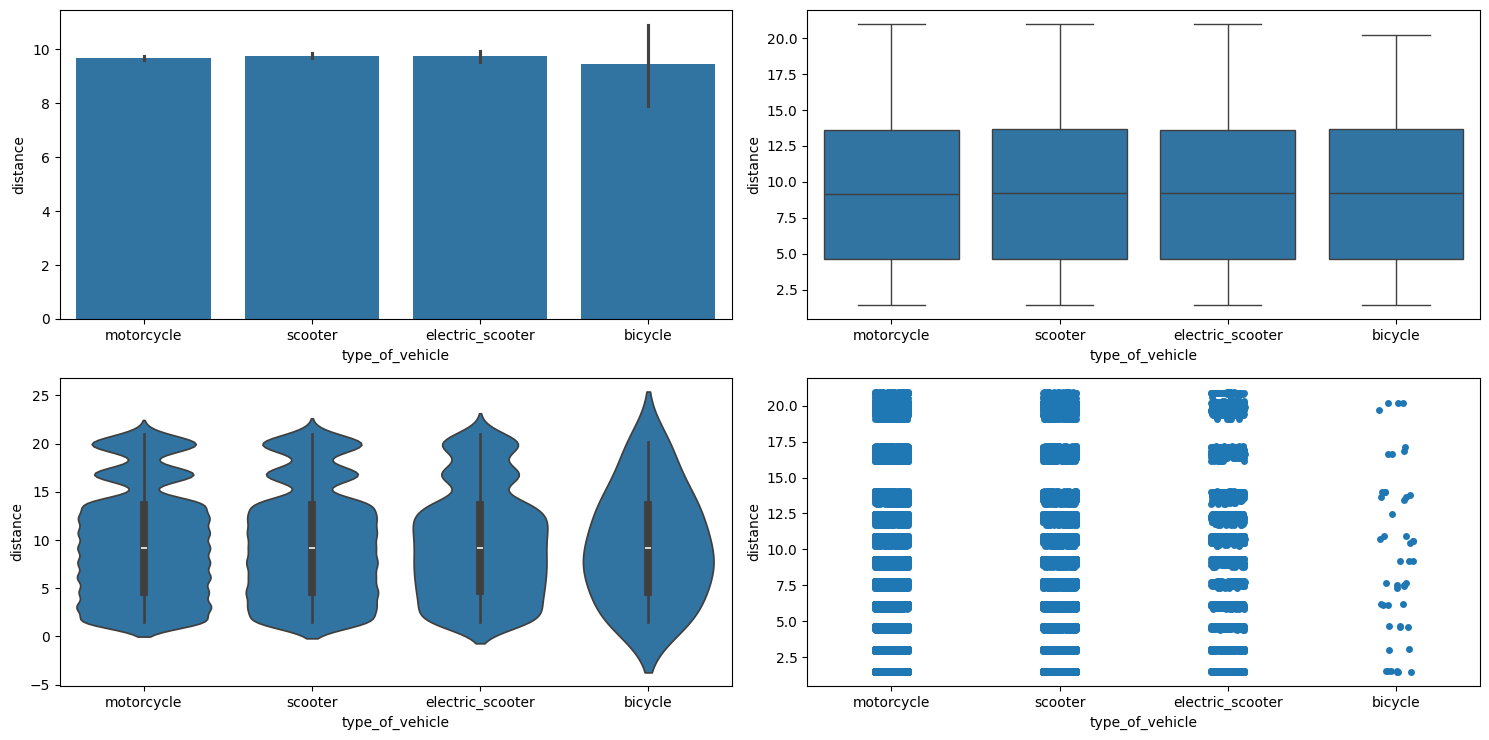

In [122]:
# vehicle type and distance analysis

numerical_categorical_analysis(df_final, "type_of_vehicle", "distance")

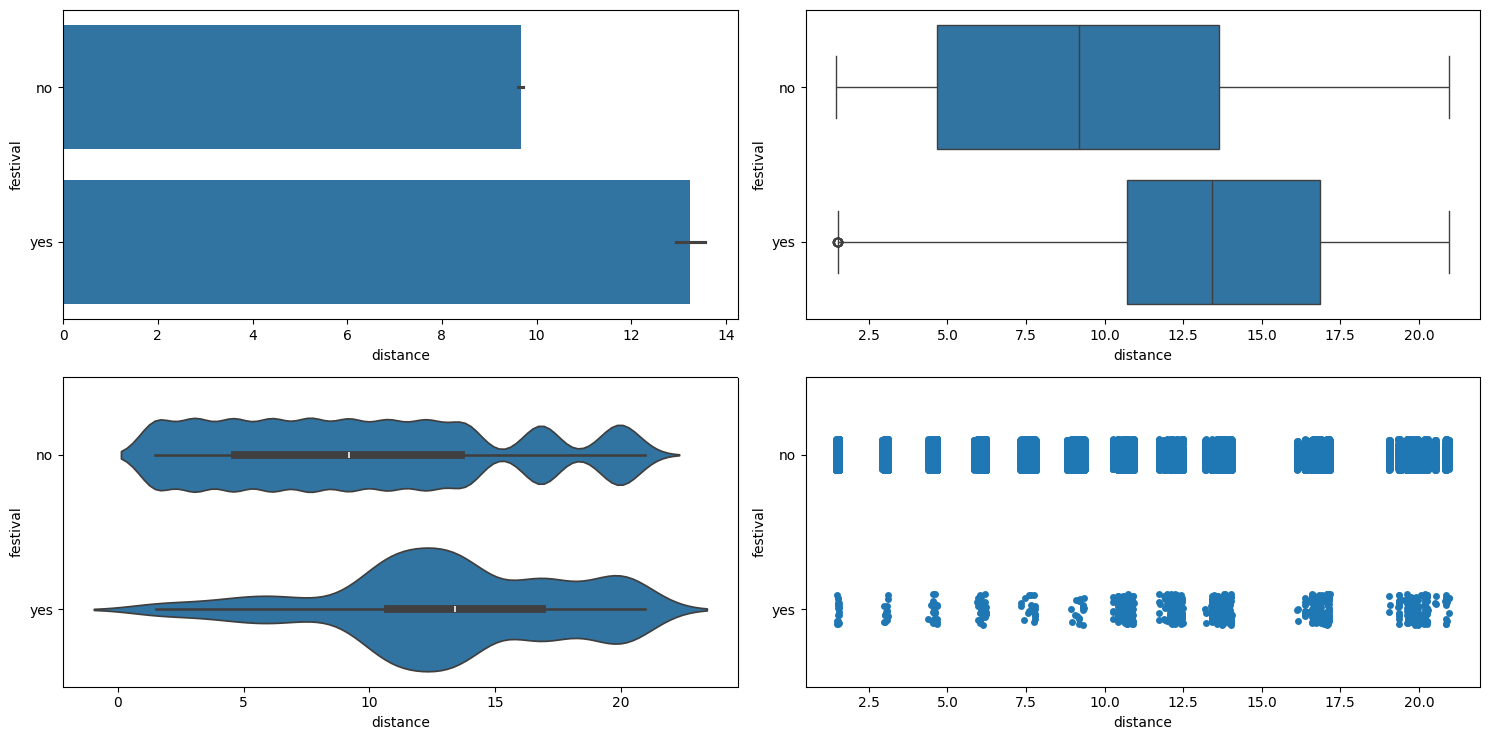

In [123]:
# do riders cover more distances during festivals

numerical_categorical_analysis(df_final, "distance", "festival")

- In festival, please order from long distances more

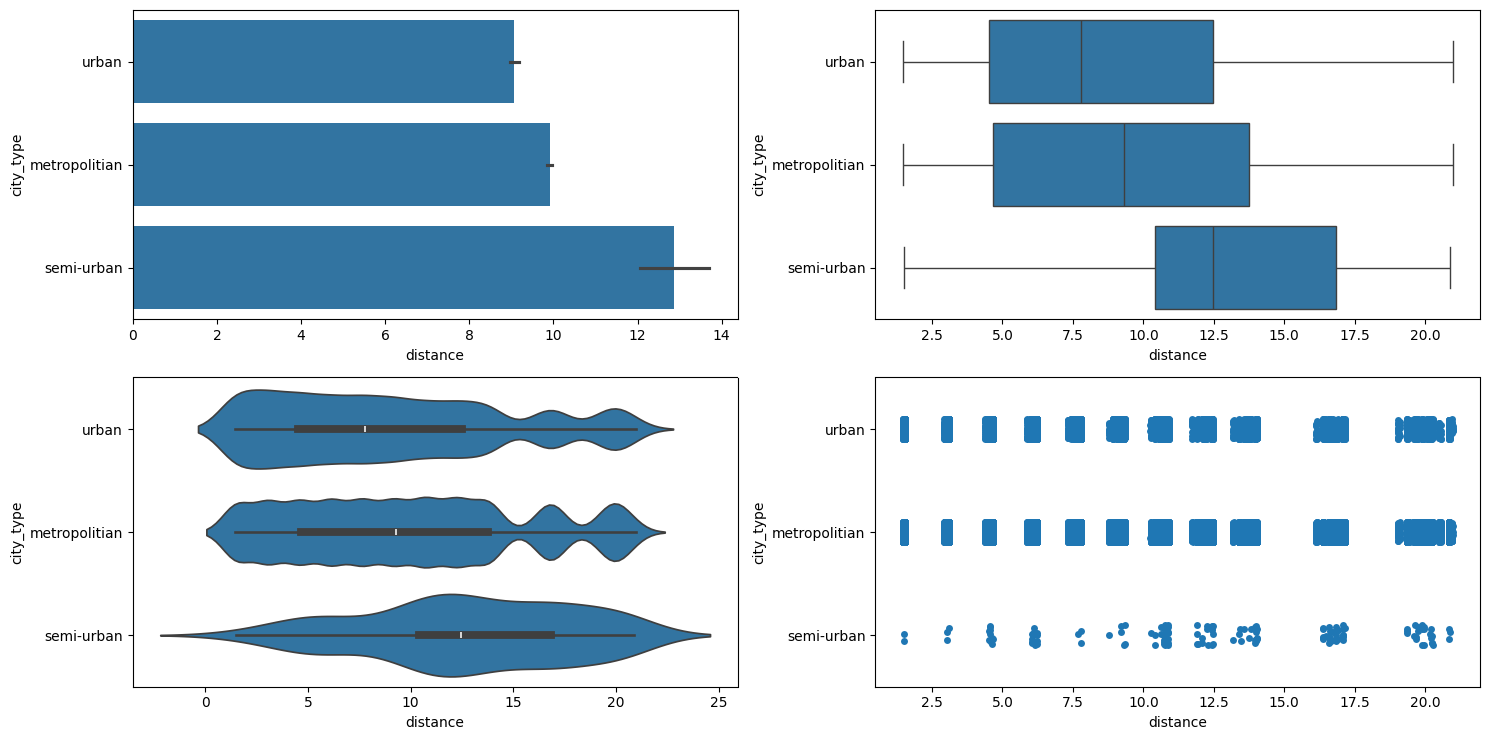

In [124]:
# distance and city type

numerical_categorical_analysis(df_final, "distance", "city_type")

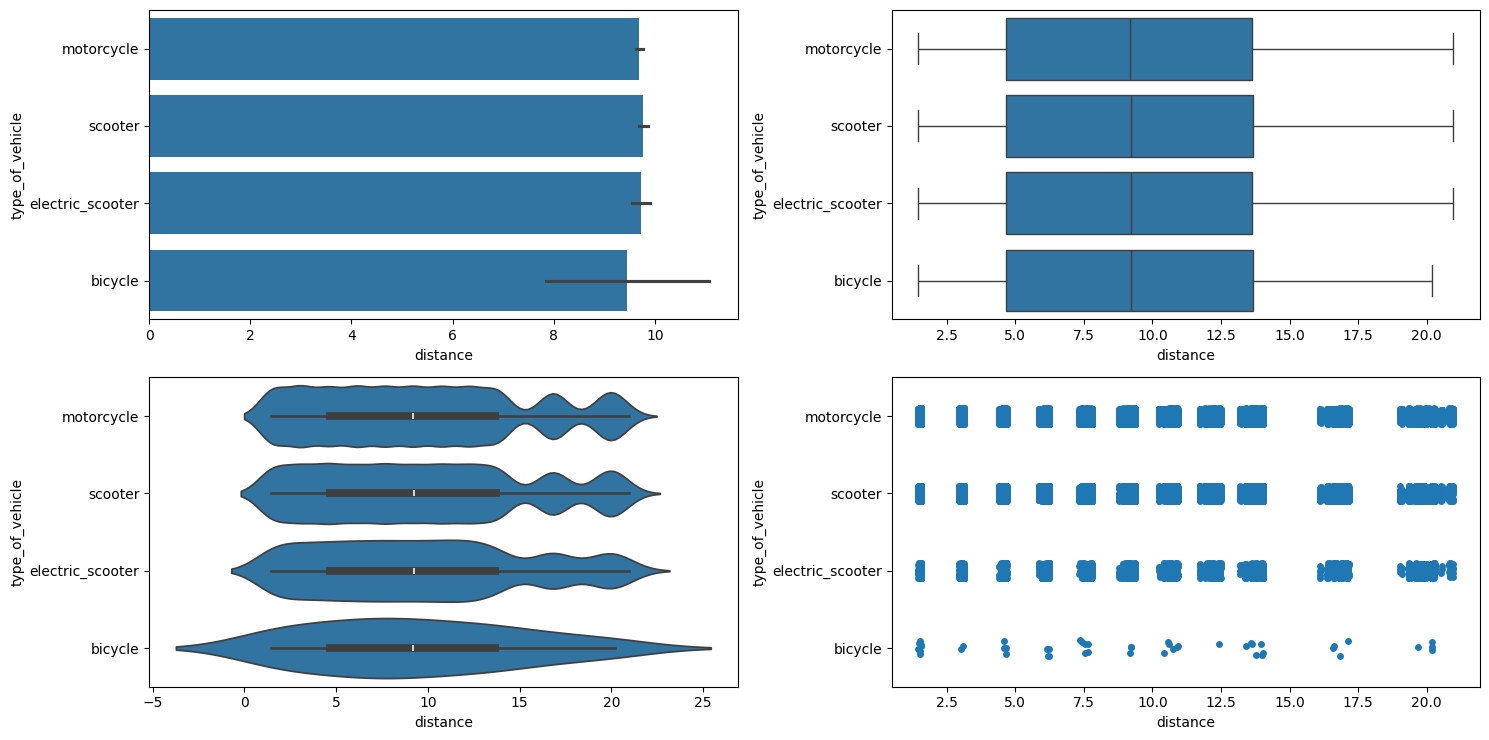

In [134]:
# does distance type affects delivery times

numerical_categorical_analysis(df_final, "distance", "type_of_vehicle")

In [ ]:
# new feature based on distance

df_final = df_final.assign(
                        distance_type = pd.cut(df_final["distance"], bins=[0, 5, 10, 15, 25],
                        right=False, labels=["short", "medium", "long", "very_long"])
                        )

In [126]:
df_final

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,time_taken_pt,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,19,3,saturday,1,15.0,11.0,morning,3.025149,-0.130153,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,25,3,friday,0,5.0,19.0,evening,20.183530,0.775092,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,19,3,saturday,1,15.0,8.0,morning,1.552758,0.088493,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,5,4,tuesday,0,10.0,18.0,evening,7.790401,-0.482135,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,26,3,saturday,1,15.0,13.0,afternoon,6.210138,0.494134,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,24,3,thursday,0,10.0,11.0,morning,1.489846,0.683422,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,16,2,wednesday,0,15.0,19.0,evening,NaN,1.039335,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,11,3,friday,0,15.0,23.0,night,4.657195,-1.151494,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,7,3,monday,0,5.0,13.0,afternoon,6.232393,0.088493,medium


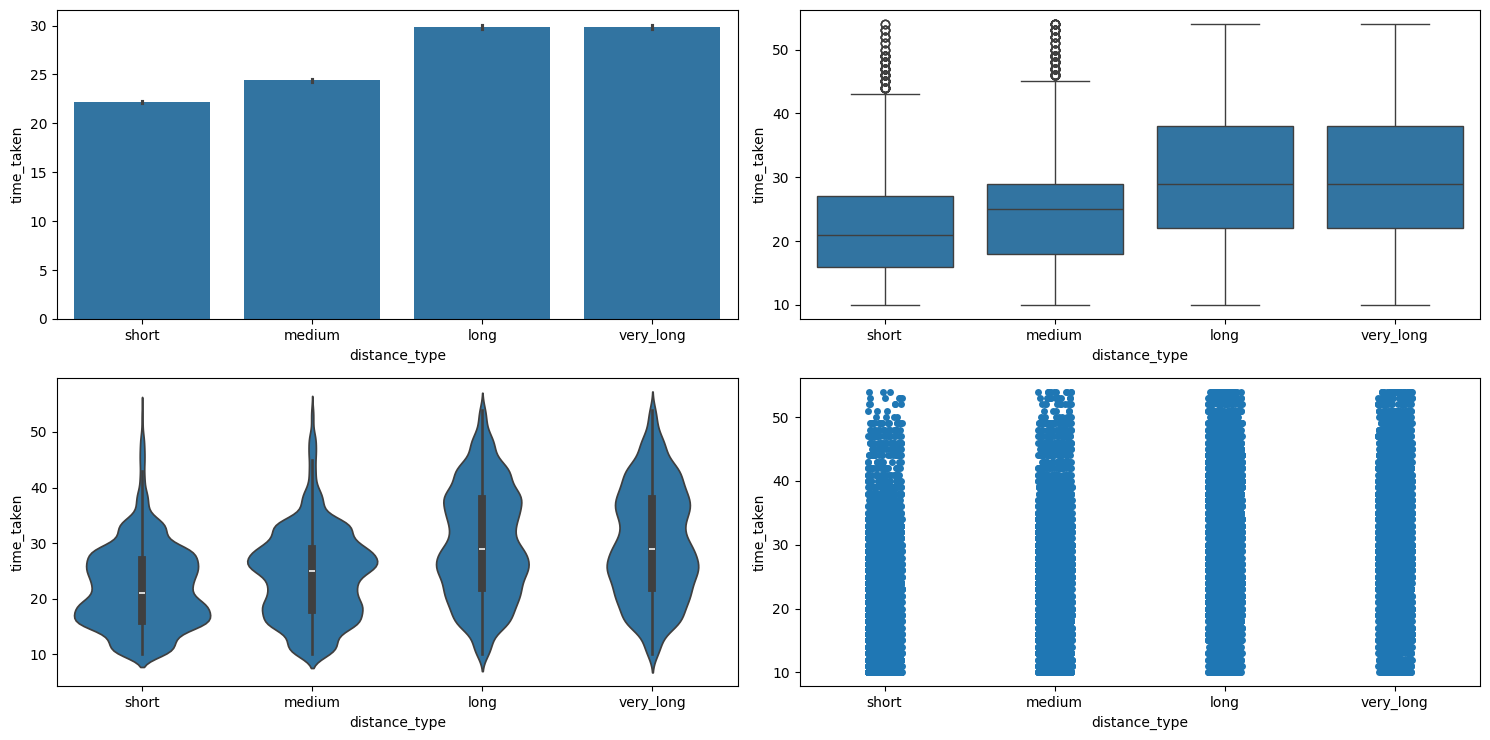

In [127]:
# does distance type affects delivery times

numerical_categorical_analysis(df_final, "distance_type", "time_taken")

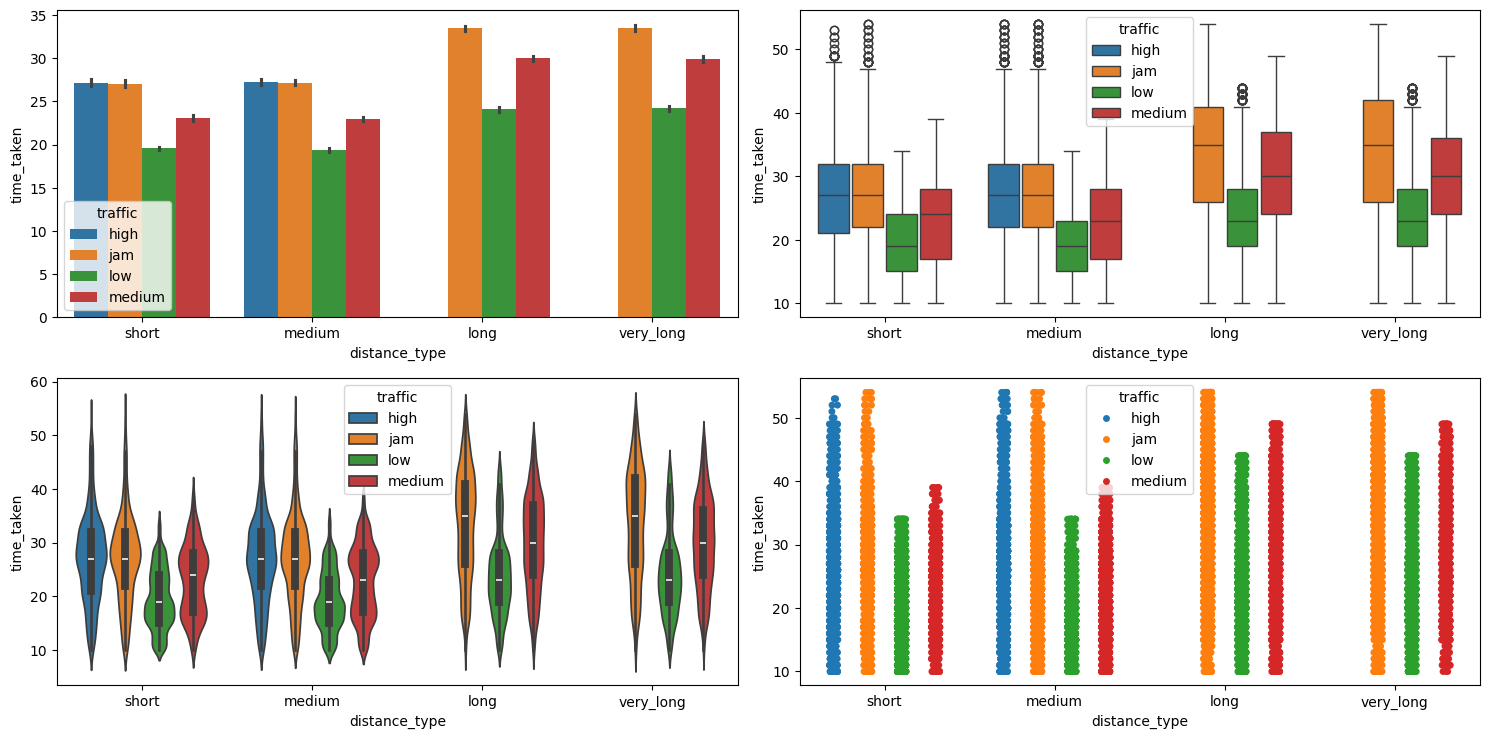

In [128]:
# delivery times based on distance and traffic

multivariate_analysis(df_final, "time_taken", "distance_type", "traffic")